## 1. Environment Setup and Library Imports
In this section, we install the necessary external dependencies and import core libraries for fuzzy logic system development, data manipulation, and visualization.
* **scikit-fuzzy**: The primary library used to build the Fuzzy Inference System (FIS).
* **matplotlib**: Utilized for plotting and visualizing the membership functions.
* **pandas & openpyxl**: Integrated for managing input data and exporting results to Excel.

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

print("Fuzzy Logic libraries imported successfully!")



Fuzzy Logic libraries imported successfully!


* **Installing missing external packages**


In [2]:
!pip install pandas-stubs
!pip install scikit-fuzzy
!pip install arabic-reshaper python-bidi
!pip install ipywidgets
!pip install openpyxl


# Section 1: Fuzzy Expert System for Smart Home Energy Management in Syria

## 1. Problem Statement & Context
Syria’s electrical grid faces severe infrastructure challenges, resulting in strict and unpredictable rationing schedules (blackouts). To adapt, Syrian households heavily rely on alternative energy sources, primarily localized photovoltaic (PV) solar systems and battery storage units.

Additionally, the Syrian Ministry of Electricity employs a progressive tariff system where electricity prices increase drastically once a household's monthly cumulative consumption surpasses the **500 kWh** threshold (moving from heavily subsidized tiers to non-subsidized, expensive tiers).

### The Proposed Solution
This project implements a **Fuzzy Expert System** using `scikit-fuzzy` to dynamically manage a smart home's energy allocation. The system continuously evaluates 5 real-world environmental and economic inputs to make 3 critical automated decisions:
1. **Grid Dependency:** To what extent should the house rely on or draw power from the government grid (balancing price vs. availability).
2. **Battery Dependency:** How much energy should be drawn from the battery bank without compromising its lifespan.
3. **Load Control (Appliance Automation):** Which categories of home appliances are permitted to run at any given moment (prioritizing essential devices over luxuries during high-tariff or low-source periods).

---

## 2. System Architecture: Inputs & Fuzzy Sets

The system processes **5 distinct input variables**, expanded into 4 explicit fuzzy sets each, mapping the complex Syrian energy reality into accurate membership transitions.

### Input Variables & Fuzzy Sets Table

| Input Variable (Antecedent) | Range / Domain | Fuzzy Set (Linguistic Term) | Brief Operational Definition |
| :--- | :--- | :--- | :--- |
| **Battery State of Charge (`battery_soc`)** | $0\% - 100\%$ | `empty` <br> `low` <br> `medium` <br> `full` | Battery is dangerously low ($<25\%$). <br> Battery is low but safe for emergencies ($20\%-55\%$). <br> Normal safe operating capacity ($45\%-80\%$). <br> Fully charged, ready for heavy discharge ($>75\%$). |
| **Solar Production (`solar_production`)** | $0\% - 100\%$ | `none` <br> `low` <br> `medium` <br> `high` | Nighttime or thick cloud cover ($<15\%$). <br> Early morning/sunset or partial shading ($10\%-50\%$). <br> Standard clear daylight production ($40\%-85\%$). <br> Peak summer midday generation ($>75\%$). |
| **Government Grid Status (`grid_status`)** | $0\% - 100\%$ | `off` <br> `very_weak` <br> `weak` <br> `stable` | Total blackout/rationing period ($<15\%$). <br> Unstable grid voltage or transition period ($10\%-45\%$). <br> Standard rationing window active ($35\%-75\%$). <br> Continuous connection (Industrial or exempted lines) ($>70\%$). |
| **Cumulative Monthly Consumption (`cum_consumption`)** | $0 - 1000\text{ kWh}$ | `subsidized` <br> `normal` <br> `borderline` <br> `expensive` | Low usage tier, cheapest government rates ($0-400\text{ kWh}$). <br> Moderate usage approaching the cap ($350-500\text{ kWh}$). <br> **The critical 500 kWh threshold window** ($480-650\text{ kWh}$). <br> Exceeded 500 kWh; highly expensive tariff active ($>600\text{ kWh}$). |
| **Current House Demand (`house_demand`)** | $0\% - 100\%$ | `basic` <br> `light_appl` <br> `heavy_appl` <br> `luxury` | Critical survival load only (LED lights, Router, Chargers) ($<30\%$). <br> Standard appliances active (Refrigerator, TV, Fans) ($25\%-60\%$). <br> Medium-heavy power devices running (Washing machine, Water pump) ($50\%-85\%$). <br> Maximum load demand (Air conditioners, Electric water heaters) ($>80\%$). |

---

## 3. System Architecture: Outputs & Fuzzy Sets

The system coordinates **3 distinct output decisions** to optimize cost, battery health, and resident comfort.

### Output Variables & Fuzzy Sets Table

| Output Variable (Consequent) | Range / Domain | Fuzzy Set (Linguistic Term) | Brief Actionable Meaning |
| :--- | :--- | :--- | :--- |
| **Battery Dependency (`battery_dependency`)** | $0\% - 100\%$ | `none` <br> `low` <br> `medium` <br> `high` | Completely isolate battery (Charge or bypass). <br> Draw minimal current for critical operations. <br> Balanced mixed-power configuration. <br> Maximize discharge to sustain the entire load independently. |
| **Grid Dependency (`grid_dependency`)** | $0\% - 100\%$ | `none` <br> `low` <br> `medium` <br> `high` | Disconnect from grid (Zero grid import / Islanded mode). <br> Limit grid import to prevent passing into expensive brackets. <br> Draw partial grid power alongside solar. <br> Maximize grid drawing to support house loads and charge batteries. |
| **Load Control / Permitted Appliances (`load_control`)** | $0\% - 100\%$ | `basics_only` <br> `light_loads` <br> `heavy_loads` <br> `full_house` | **Emergency Mode:** Shed all loads except LED lighting and Router. <br> **Eco Mode:** Allow basic loads + Refrigerator and TV. <br> **Comfort Mode:** Allow light loads + Washing Machine or Water Pump. <br> **Full Mode:** Run everything safely, including Air Conditioning. |

---

## 4. Input Configuration Diagram (Mathematical Overlaps)

The following ASCII graph illustrates how the system's inputs transition dynamically, with special emphasis on how the **Cumulative Monthly Consumption** changes its fuzzy behavior precisely around the **500 kWh** economic turning point:

# القسم الأول: نظام خبير ضبابي لإدارة الطاقة المنزلية الذكية في سوريا

## 1. صياغة المشكلة والسياق العام (Problem Statement & Context)
تواجه شبكة الكهرباء العامة في سوريا تحديات بنيوية كبيرة، تؤدي إلى تطبيق برنامج تقنين صارم وغير منتظم (ساعات وصل وانقطاع متغيرة). للتكيف مع هذا واقع، تعتمد المنازل السورية بشكل أساسي على مصادر طاقة بديلة، وفي مقدمتها منظومة الطاقة الشمسية الكهروضوئية (PV) ووحدات تخزين الطاقة (البطاريات).

علاوة على ذلك، تعتمد وزارة الكهرباء نظام شرائح تصاعدي للفوترة، حيث ترتفع أسعار الكهرباء بشكل حاد بمجرد تجاوز الاستهلاك المتراكم للمنزل حاجز الـ **500 كيلوواط ساعي (kWh)** شهرياً، والانتقال من النطاق المدعوم حكومياً إلى نطاق الاستهلاك غير المدعوم ذي التكلفة المرتفعة.

### الحل المقترح
يقوم هذا المشروع على بناء **نظام خبير ضبابي (Fuzzy Expert System)** باستخدام مكتبة `skfuzzy` لإدارة وتوزيع طاقة المنزل الذكي ديناميكياً. يقوم النظام بتقييم 5 مدخلات واقعية لبيئة الطاقة في سوريا لاتخاذ 3 قرارات أتمتة حاسمة:
1. **الاعتماد على الكهرباء الحكومية:** تحديد نسبة السحب من الشبكة العامة موازنةً بين السعر والتوفر.
2. **الاعتماد على البطاريات:** تحديد كمية الطاقة المسحوبة من بنك البطاريات بما يضمن تلبية الحاجة دون الإضرار بعمرها الافتراضي.
3. **التحكم بالأحمال (أتمتة الأجهزة):** تحديد فئات الأجهزة المنزلية المسموح بتشغيلها في كل لحظة، وتقديم الأجهزة الأساسية على أجهزة الرفاهية في أوقات غياب المصادر أو ارتفاع التعرفة السعرية.

---

## 2. بنية النظام: المدخلات والمجموعات الضبابية (Inputs & Fuzzy Sets)

يتعامل النظام مع **5 متغيرات مدخلة منفصلة**، تم تقسيم كل منها إلى 4 مجموعات ضبابية صريحة، لنمذجة واقع الطاقة وتحقيق انتقالات رياضية دقيقة.

### جدول متغيرات الدخل والمجموعات الضبابية

| متغير الدخل (Antecedent) | النطاق الرقمي | المجموعة الضبابية (Linguistic Term) | التعريف الإجرائي المختصر |
| :--- | :--- | :--- | :--- |
| **حالة شحن البطارية (`battery_soc`)** | $0\% - 100\%$ | `empty` <br> `low` <br> `medium` <br> `full` | البطارية في مستويات تفريغ حرجة ومقتربة من الفصل ($0\%-25\%$). <br> البطارية منخفضة لكنها كافية لحالات الطوارئ ($20\%-55\%$). <br> سعة تشغيل آمنة وطبيعية ($45\%-80\%$). <br> مشحونة بالكامل وجاهزة للتفريغ العالي ($75\%-100\%$). |
| **الإنتاج الشمسي (`solar_production`)** | $0\% - 100\%$ | `none` <br> `low` <br> `medium` <br> `high` | فترة ليلية أو غيوم كثيفة جداً وانعدام التوليد ($0\%-15\%$). <br> الصباح الباكر/الغروب أو وجود ظلال جزئية تعيق التوليد ($10\%-50\%$). <br> إنتاج نهار مشمس بمعدلات طبيعية مستقرة ($40\%-85\%$). <br> ذروة التوليد في ظهيرة الصيف الصافية ($75\%-100\%$). |
| **حالة الشبكة الحكومية (`grid_status`)** | $0\% - 100\%$ | `off` <br> `very_weak` <br> `weak` <br> `stable` | انقطاع كامل للكهرباء وفترة تقنين ممتدة ($0\%-25\%$). <br> جهد الشبكة غير مستقر أو لحظات تذبذب الوصل وفصل الحمايات ($15\%-45\%$). <br> نافذة الوصل النظامية المحدودة متوفرة بجهد مقبول ($35\%-75\%$). <br> خطوط معفاة من التقنين أو وصل مستقر مستمر لفترات طويلة ($60\%-100\%$). |
| **الاستهلاك المتراكم الشهري (`cum_consumption`)** | $0 - 1000\text{ kWh}$ | `subsidized` <br> `normal` <br> `borderline` <br> `expensive` | شريحة الاستهلاك الدنيا بأرخص الأسعار الحكومية المدعومة ($0-400\text{ kWh}$). <br> استهلاك متوسط يقترب من سقف الدعم ($350-500\text{ kWh}$). <br> **مرحلة الخطر الحرجة حول حاجز الـ 500 kWh** ($450-600\text{ kWh}$). <br> تجاوز حاجز الـ 500 والولوج في تعرفة مرتفعة التكلفة ($550-1000\text{ kWh}$). |
| **طلب المنزل الحالي (`house_demand`)** | $0\% - 100\%$ | `basic` <br> `light_appl` <br> `heavy_appl` <br> `luxury` | أحمال استمرار الحياة الأساسية فقط كالإضاءة والإنترنت والشواحن ($0\%-30\%$). <br> أجهزة تشغيل تقليدية مستمرة كالبراد والتلفزيون والمراوح ($25\%-60\%$). <br> أجهزة سحب طاقة متوسطة إلى ثقيلة كالغسالة ومضخة المياه ($50\%-85\%$). <br> ذروة طلب الطاقة الرفاهية كالمكيفات وسخانات المياه الكهربائية ($65\%-100\%$). |

---

## 3. بنية النظام: المخرجات والمجموعات الضبابية (Outputs & Fuzzy Sets)

ينظم النظام **3 قرارات مخرجة منفصلة** لتحقيق التوازن الأمثل بين التكلفة المادية، وصحة البطارية، وراحة الساكنين.

### جدول متغيرات الخرج والمجموعات الضبابية

| متغير الخرج (Consequent) | النطاق الرقمي | المجموعة الضبابية (Linguistic Term) | المعنى الإجرائي للقرار |
| :--- | :--- | :--- | :--- |
| **الاعتماد على البطاريات (`battery_dependency`)** | $0\% - 100\%$ | `none` <br> `low` <br> `medium` <br> `high` | فصل البطارية تماماً عن الاستهلاك لحمايتها أو شحنها ($0\%-15\%$). <br> سحب أدنى كمية تيار ممكنة للعمليات الحرجة فقط ($10\%-55\%$). <br> نمط تشغيل مختلط متوازن الطاقة مع مصادر أخرى ($45\%-85\%$). <br> الاعتماد الأقصى على التفريغ لتشغيل المنزل بشكل مستقل ($75\%-100\%$). |
| **الاعتماد على الشبكة الحكومية (`grid_dependency`)** | $0\% - 100\%$ | `none` <br> `low` <br> `medium` <br> `high` | فصل كلي عن الشبكة الحكومية والاعتماد الذاتي الكامل ($0\%-15\%$). <br> تقييد السحب من الشبكة لتجنب الانتقال لشرائح سعرية أعلى ($10\%-55\%$). <br> سحب جزئي متوازن من الشبكة بالتوازي مع الطاقة البديلة ($45\%-85\%$). <br> سحب أقصى من الشبكة لتغطية الأحمال الكبيرة وشحن البطاريات ($75\%-100\%$). |
| **التحكم بالأحمال / الأجهزة المسموحة (`load_control`)** | $0\% - 100\%$ | `basics_only` <br> `light_loads` <br> `heavy_loads` <br> `full_house` | **وضع الطوارئ:** فصل جميع الأحمال عدا الإضاءة الأساسية والإنترنت ($0\%-35\%$). <br> **الوضع الاقتصادي:** السماح بالأحمال الأساسية والبراد والتلفزيون ($25\%-65\%$). <br> **وضع الراحة:** السماح بالأحمال المتوسطة والثقيلة كالغسالة أو المضخة ($55\%-90\%$). <br> **الوضع الكامل:** تشغيل كل شيء بأمان بما في ذلك التكييف والرفاهية ($85\%-100\%$). |

---

## 4. مخطط إعدادات الدخل والتداخلات الرياضية

يوضح المخطط البياني التالي بكود الـ ASCII كيفية انتقال حالات النظام ديناميكياً، مع التركيز على سلوك **الاستهلاك المتراكم الشهري** وتغير منحنياته الضبابية بدقة حول نقطة التحول الاقتصادي المتمثلة في **500 كيلوواط ساعي**:

## 1. Environment Setup and Library Imports
In this section, we install the necessary external dependencies and import core libraries for fuzzy logic system development, data manipulation, and visualization.
* **scikit-fuzzy**: The primary library used to build the Fuzzy Inference System (FIS).
* **matplotlib**: Utilized for plotting and visualizing the membership functions.
* **pandas & openpyxl**: Integrated for managing input data and exporting results to Excel.

In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [56]:


soc_range = np.arange(0, 101, 1)          # البطارية (0-100%)
solar_range = np.arange(0, 101, 1)        # الشمس (0-100%)
grid_range = np.arange(0, 101, 1)         # الشبكة الحكومية (0-100%)
consumption_range = np.arange(0, 1001, 1) # الاستهلاك المتراكم الشهري (0-1000 kWh)
demand_range = np.arange(0, 101, 1)       # طلب البيت الحالي (0-100%)
output_range = np.arange(0, 101, 1)       # نطاق المخرجات الموحد (0-100%)

In [57]:
battery_soc      = ctrl.Antecedent(soc_range, 'battery_soc')
solar_production = ctrl.Antecedent(solar_range, 'solar_production')
grid_status      = ctrl.Antecedent(grid_range, 'grid_status')
cum_consumption  = ctrl.Antecedent(consumption_range, 'cum_consumption')
house_demand     = ctrl.Antecedent(demand_range, 'house_demand')

In [58]:


battery_dependency = ctrl.Consequent(output_range, 'battery_dependency')
grid_dependency    = ctrl.Consequent(output_range, 'grid_dependency')
load_control       = ctrl.Consequent(output_range, 'load_control')

In [59]:

battery_soc['empty']  = fuzz.trapmf(soc_range, [0, 0, 15, 25])
battery_soc['low']    = fuzz.trimf(soc_range, [20, 35, 55])
battery_soc['medium'] = fuzz.trimf(soc_range, [45, 65, 80])
battery_soc['full']   = fuzz.trapmf(soc_range, [75, 90, 100, 100])

# دالات الطاقة الشمسية (توسيع إلى 4 حالات)
solar_production['none']   = fuzz.trapmf(solar_range, [0, 0, 5, 15])
solar_production['low']    = fuzz.trimf(solar_range, [10, 30, 50])
solar_production['medium'] = fuzz.trimf(solar_range, [40, 65, 85])
solar_production['high']   = fuzz.trapmf(solar_range, [75, 90, 100, 100])

# دالات الشبكة الحكومية (توسيع إلى 4 حالات تحاكي بدقة واقع التقنين والوصل)
grid_status['off']       = fuzz.trapmf(grid_range, [0, 0, 5, 15])        # مقطوعة تماماً
grid_status['very_weak'] = fuzz.trimf(grid_range, [10, 25, 45])         # تأتي نبضات أو كهرباء غير مستقرة
grid_status['weak']      = fuzz.trimf(grid_range, [35, 55, 75])         # تقنين عادي (ساعة وصل مثلاً بجودة متوسطة)
grid_status['stable']    = fuzz.trapmf(grid_range, [70, 85, 100, 100])   # خطوط معفاة من التقنين أو وصل مستقر

# دالات الاستهلاك المتراكم (توسيع إلى 4 حالات لتغطية شرائح الفاتورة وحاجز الـ 500 بدقة)
cum_consumption['subsidized'] = fuzz.trapmf(consumption_range, [0, 0, 250, 400])     # شريحة رخيصة جداً
cum_consumption['normal']     = fuzz.trimf(consumption_range, [350, 450, 500])       # شريحة متوسطة تحت حاجز الدعم
cum_consumption['borderline'] = fuzz.trimf(consumption_range, [480, 530, 650])       # شريحة الخطر حول الـ 500 kWh
cum_consumption['expensive']  = fuzz.trapmf(consumption_range, [600, 750, 1000, 1000]) # شريحة التجاري والرفاهية الغالية

# طبيعة استهلاك البيت الحالي (توسيع إلى 4 حالات لتغطية كل أنواع الأجهزة)
house_demand['basic']      = fuzz.trapmf(demand_range, [0, 0, 15, 30])     # إنارة، راوتر، شواحن
house_demand['light_appl']  = fuzz.trimf(demand_range, [25, 45, 60])        # براد، تلفزيون، مروحة
house_demand['heavy_appl']  = fuzz.trimf(demand_range, [50, 70, 85])        # غسالة، مضخة مياه، مكواة
house_demand['luxury']      = fuzz.trapmf(demand_range, [80, 90, 100, 100])   # مكيفات، سخانات مياه كهربائية

# ==============================================================================
# 4. دالات الانتماء للمخرجات بعد التوسيع (Outputs)
# ==============================================================================

# مخرج 1: نسبة الاعتماد على البطاريات (توسيع إلى 4 حالات)
battery_dependency['none']   = fuzz.trapmf(output_range, [0, 0, 5, 15])
battery_dependency['low']    = fuzz.trimf(output_range, [10, 35, 55])
battery_dependency['medium'] = fuzz.trimf(output_range, [45, 70, 85])
battery_dependency['high']   = fuzz.trapmf(output_range, [75, 90, 100, 100])

# مخرج 2: نسبة الاعتماد على الطاقة الحكومية (توسيع إلى 4 حالات)
grid_dependency['none']   = fuzz.trapmf(output_range, [0, 0, 5, 15])
grid_dependency['low']    = fuzz.trimf(output_range, [10, 35, 55])
grid_dependency['medium'] = fuzz.trimf(output_range, [45, 70, 85])
grid_dependency['high']   = fuzz.trapmf(output_range, [75, 90, 100, 100])

# مخرج 3: شو بدي شغل - طبيعة الأحمال المسموحة (توسيع كامل إلى 4 حالات واضحة جداً)
load_control['basics_only']   = fuzz.trapmf(output_range, [0, 0, 20, 35])     # ليد وراوتر فقط
load_control['light_loads']   = fuzz.trimf(output_range, [25, 45, 65])        # إضافة البراد والتلفزيون
load_control['heavy_loads']   = fuzz.trimf(output_range, [55, 75, 90])        # تشغيل الغسالة أو المضخات
load_control['full_house']    = fuzz.trapmf(output_range, [85, 95, 100, 100])  # تشغيل المكيفات وكامل الرفاهية

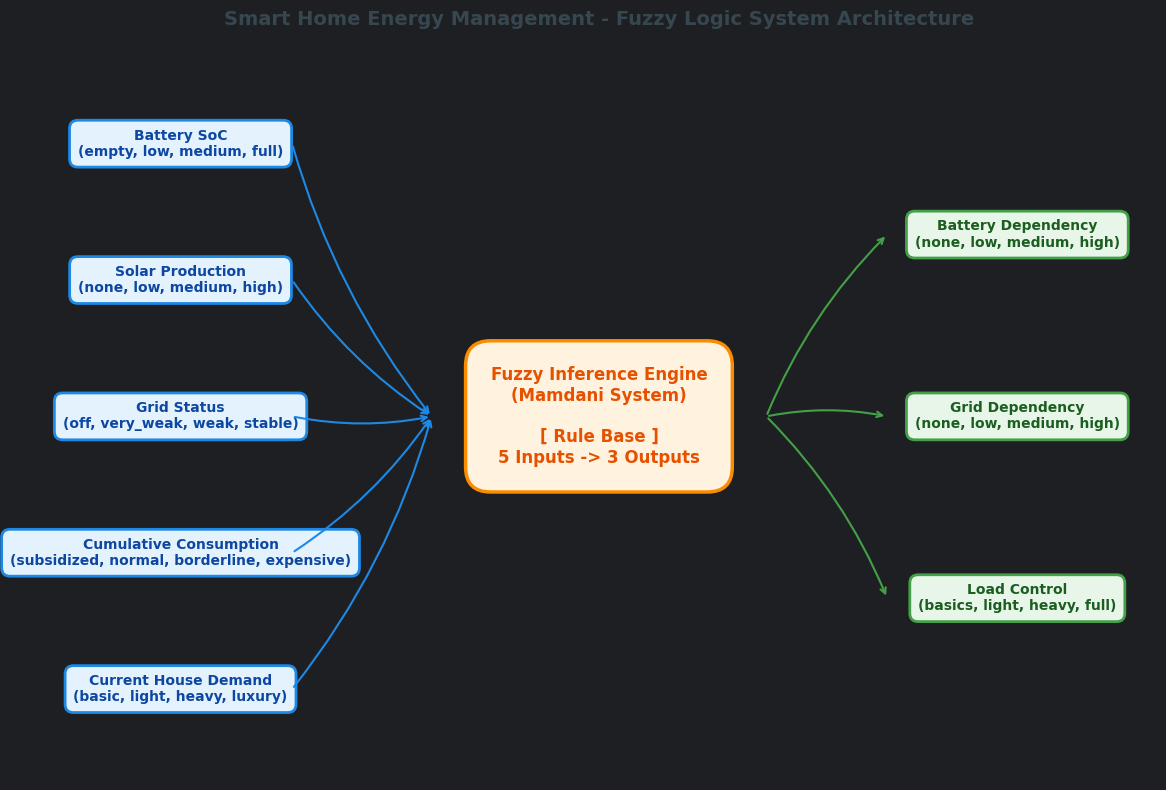

 Fuzzy_System_Architecture.png


In [60]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#f8f9fa')

inputs = [
    "Battery SoC\n(empty, low, medium, full)",
    "Solar Production\n(none, low, medium, high)",
    "Grid Status\n(off, very_weak, weak, stable)",
    "Cumulative Consumption\n(subsidized, normal, borderline, expensive)",
    "Current House Demand\n(basic, light, heavy, luxury)"
]

outputs = [
    "Battery Dependency\n(none, low, medium, high)",
    "Grid Dependency\n(none, low, medium, high)",
    "Load Control\n(basics, light, heavy, full)"
]

y_inputs = np.linspace(7, 1, 5)
for i, inp in enumerate(inputs):
    ax.text(1.5, y_inputs[i], inp, bbox=dict(boxstyle="round,pad=0.6", facecolor='#e3f2fd', edgecolor='#1e88e5', lw=2),
            ha="center", va="center", fontsize=10, fontweight='bold', color='#0d47a1')

ax.text(6, 4, "Fuzzy Inference Engine\n(Mamdani System)\n\n[ Rule Base ]\n5 Inputs -> 3 Outputs",
        bbox=dict(boxstyle="round,pad=1.5", facecolor='#fff3e0', edgecolor='#fb8c00', lw=2.5),
        ha="center", va="center", fontsize=12, fontweight='bold', color='#e65100')

y_outputs = np.linspace(6, 2, 3)
for i, outp in enumerate(outputs):
    ax.text(10.5, y_outputs[i], outp, bbox=dict(boxstyle="round,pad=0.6", facecolor='#e8f5e9', edgecolor='#43a047', lw=2),
            ha="center", va="center", fontsize=10, fontweight='bold', color='#1b5e20')

for y_in in y_inputs:
    ax.annotate('', xy=(4.2, 4), xytext=(2.7, y_in),
                arrowprops=dict(arrowstyle="->", color='#1e88e5', lw=1.5, connectionstyle="arc3,rad=0.1"))

for y_out in y_outputs:
    ax.annotate('', xy=(9.1, y_out), xytext=(7.8, 4),
                arrowprops=dict(arrowstyle="->", color='#43a047', lw=1.5, connectionstyle="arc3,rad=-0.1"))

ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')
plt.title("Smart Home Energy Management - Fuzzy Logic System Architecture", fontsize=14, fontweight='bold', pad=20, color='#37474f')

plt.tight_layout()
plt.savefig('Fuzzy_System_Architecture.png', dpi=300)
plt.show()

print(" Fuzzy_System_Architecture.png")

In [61]:
!pip install arabic-reshaper python-bidi

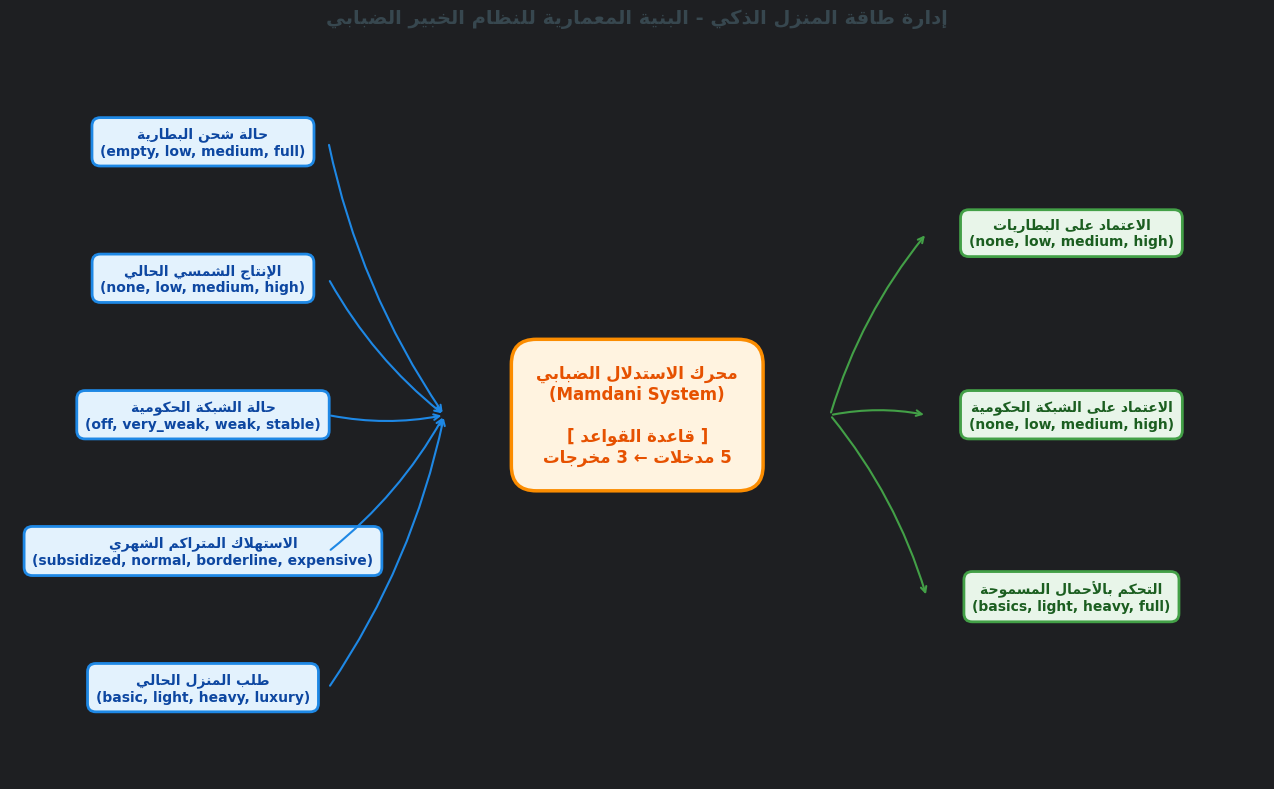

 Fuzzy_System_Architecture_AR.png


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

fig, ax = plt.subplots(figsize=(13, 8))
ax.set_facecolor('#f8f9fa')

inputs = [
    fix_arabic("حالة شحن البطارية\n(empty, low, medium, full)"),
    fix_arabic("الإنتاج الشمسي الحالي\n(none, low, medium, high)"),
    fix_arabic("حالة الشبكة الحكومية\n(off, very_weak, weak, stable)"),
    fix_arabic("الاستهلاك المتراكم الشهري\n(subsidized, normal, borderline, expensive)"),
    fix_arabic("طلب المنزل الحالي\n(basic, light, heavy, luxury)")
]

outputs = [
    fix_arabic("الاعتماد على البطاريات\n(none, low, medium, high)"),
    fix_arabic("الاعتماد على الشبكة الحكومية\n(none, low, medium, high)"),
    fix_arabic("التحكم بالأحمال المسموحة\n(basics, light, heavy, full)")
]

y_inputs = np.linspace(7, 1, 5)
for i, inp in enumerate(inputs):
    ax.text(2.0, y_inputs[i], inp, bbox=dict(boxstyle="round,pad=0.6", facecolor='#e3f2fd', edgecolor='#1e88e5', lw=2),
            ha="center", va="center", fontsize=10, fontweight='bold', color='#0d47a1')

engine_text = fix_arabic("محرك الاستدلال الضبابي") + "\n(Mamdani System)\n\n" + fix_arabic("[ قاعدة القواعد ]") + "\n" + fix_arabic("5 مدخلات ← 3 مخرجات")
ax.text(6.5, 4, engine_text,
        bbox=dict(boxstyle="round,pad=1.5", facecolor='#fff3e0', edgecolor='#fb8c00', lw=2.5),
        ha="center", va="center", fontsize=12, fontweight='bold', color='#e65100')

y_outputs = np.linspace(6, 2, 3)
for i, outp in enumerate(outputs):
    ax.text(11.0, y_outputs[i], outp, bbox=dict(boxstyle="round,pad=0.6", facecolor='#e8f5e9', edgecolor='#43a047', lw=2),
            ha="center", va="center", fontsize=10, fontweight='bold', color='#1b5e20')

for y_in in y_inputs:
    ax.annotate('', xy=(4.5, 4), xytext=(3.3, y_in),
                arrowprops=dict(arrowstyle="->", color='#1e88e5', lw=1.5, connectionstyle="arc3,rad=0.1"))

for y_out in y_outputs:
    ax.annotate('', xy=(9.5, y_out), xytext=(8.5, 4),
                arrowprops=dict(arrowstyle="->", color='#43a047', lw=1.5, connectionstyle="arc3,rad=-0.1"))

ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis('off')

main_title = fix_arabic("إدارة طاقة المنزل الذكي - البنية المعمارية للنظام الخبير الضبابي")
plt.title(main_title, fontsize=14, fontweight='bold', pad=20, color='#37474f')

plt.tight_layout()
plt.savefig('Fuzzy_System_Architecture_AR.png', dpi=300)
plt.show()

print(" Fuzzy_System_Architecture_AR.png")

## 5. Visualizing Membership Functions
To verify the design and alignment of our fuzzy sets, we generate visual plots for all input and output variables. This graphic validation ensures that the overlapping regions represent realistic control transitions.

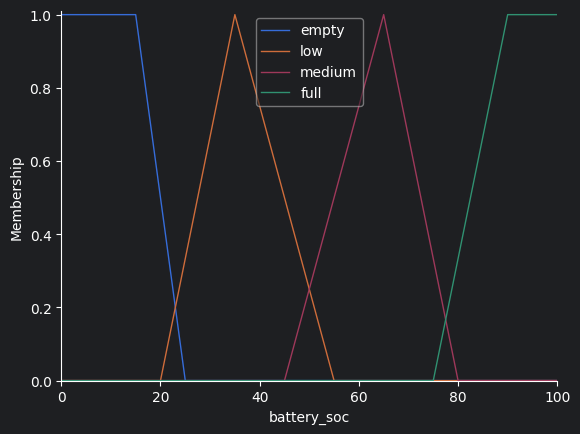

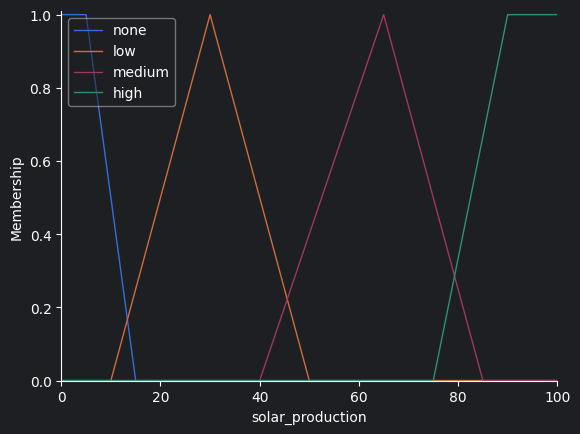

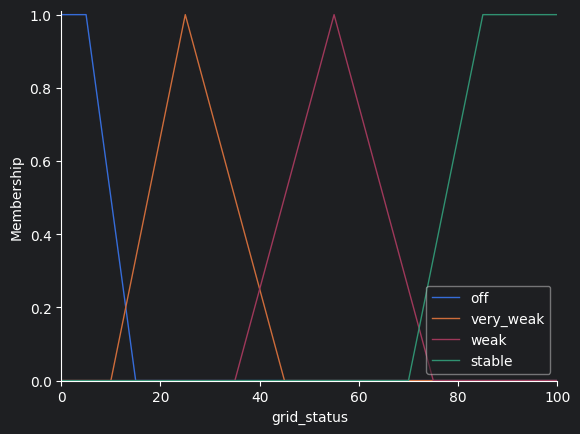

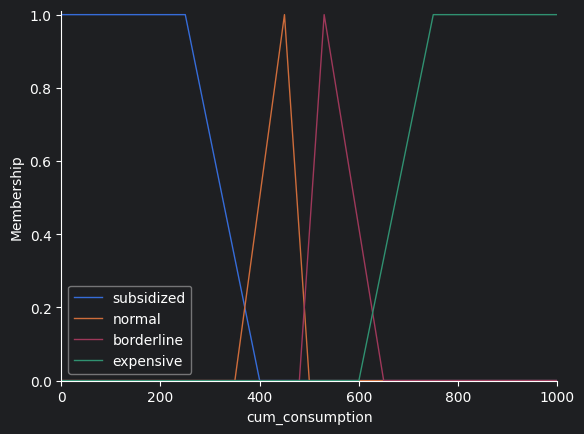

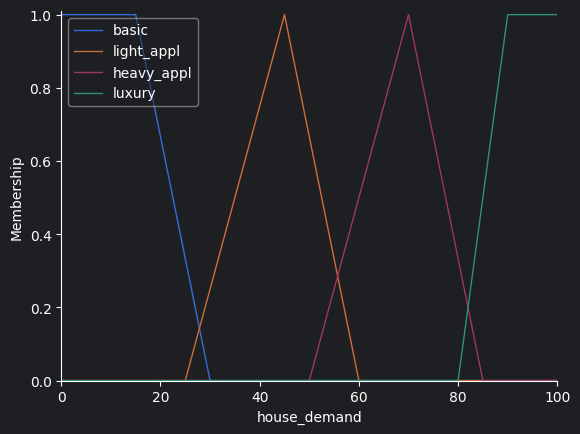

In [63]:
import matplotlib.pyplot as plt
import warnings

# إخفاء التنبيهات المزعجة الخاصة بالمكتبات الخارجية
warnings.filterwarnings("ignore", category=UserWarning)

# الآن استدعي دالات العرض بشكل طبيعي مع إضافة plt.show() بعد كل واحدة
battery_soc.view()
plt.show()

solar_production.view()
plt.show()

grid_status.view()
plt.show()

cum_consumption.view()
plt.show()

house_demand.view()
plt.show()

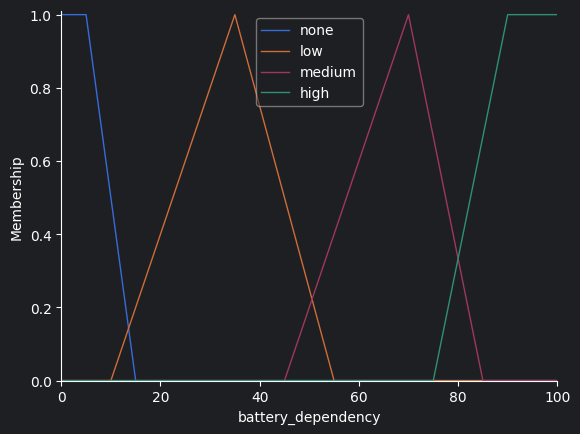

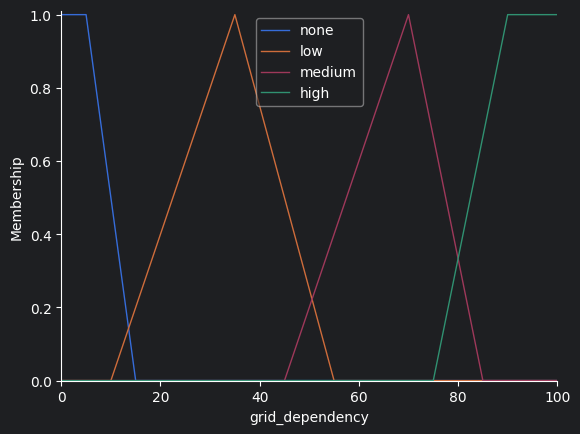

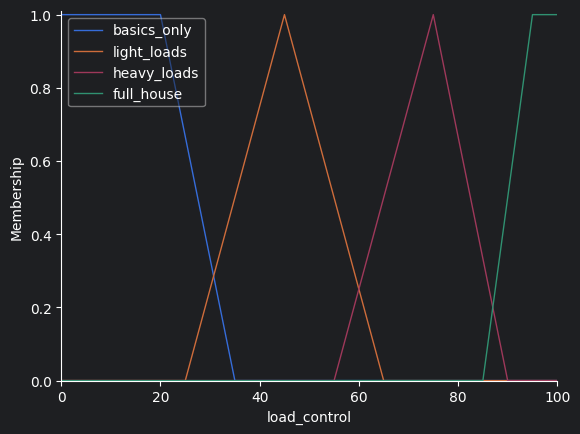

In [64]:

battery_dependency.view()
grid_dependency   .view()
load_control     .view()

## 5. Visualizing Dynamic Membership Functions via Subplots
This section renders all five inputs dynamically. By utilizing the minimum and maximum boundaries of each variable's universe vector individually, we fix axis truncation errors—ensuring variables with larger scales (like cumulative consumption) are plotted accurately within the dashboard grid.

In [65]:

# battery_soc
# solar_production
# grid_status
# cum_consumption
# house_demand


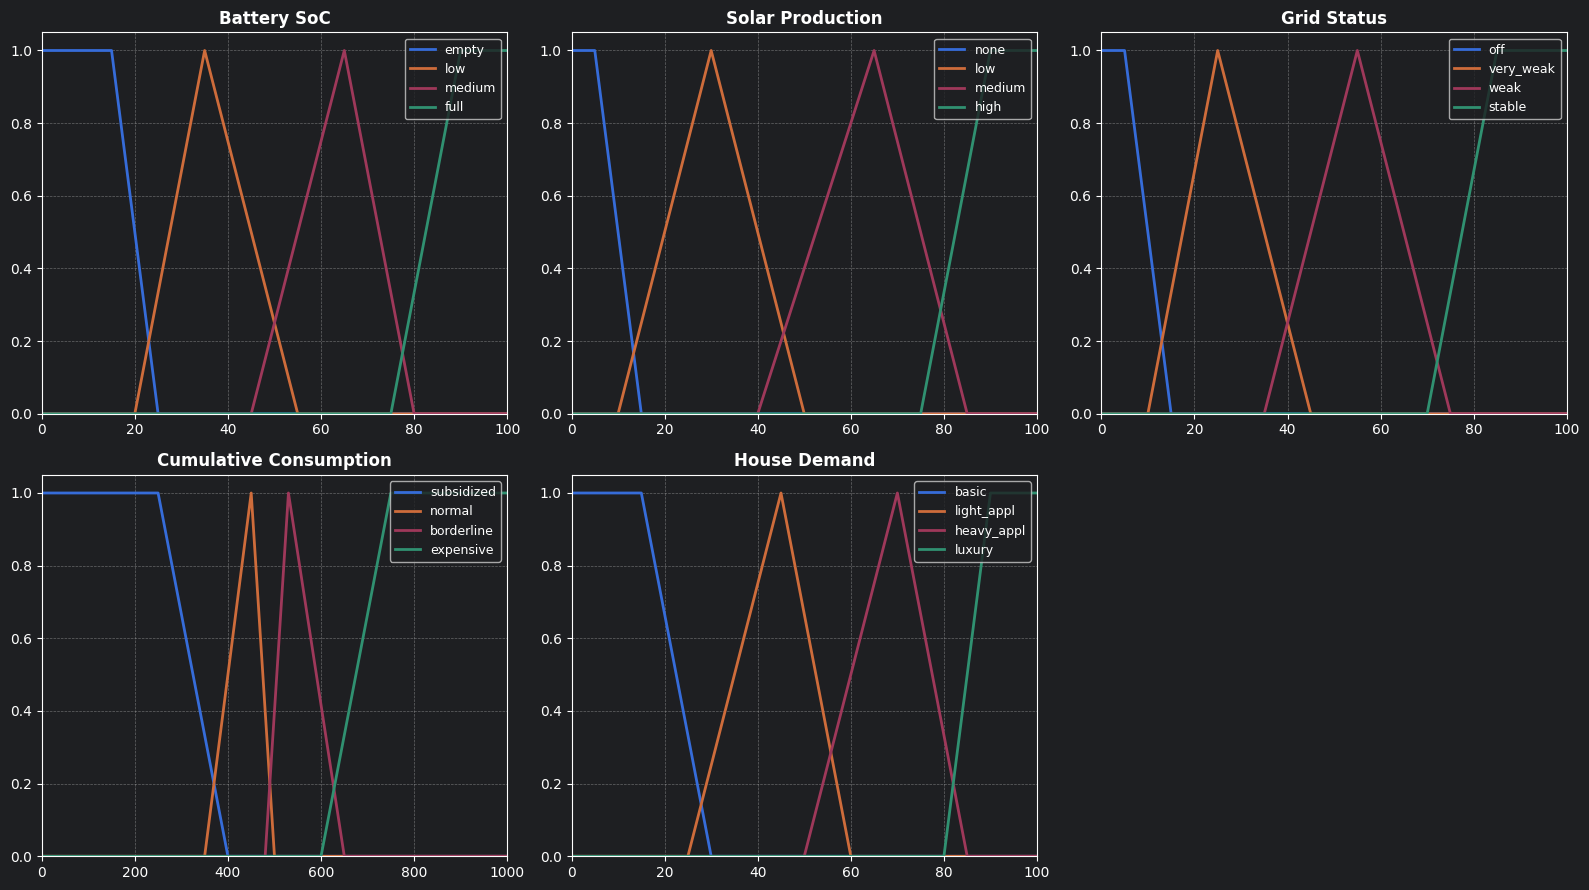

In [66]:
import matplotlib.pyplot as plt

# List of your input objects and their custom display titles
inputs_list = [


    (battery_soc, 'Battery SoC'),
    (solar_production, 'Solar Production'),
    (grid_status, 'Grid Status'),
    (cum_consumption, 'Cumulative Consumption'),
    (house_demand, 'House Demand')
]

# Create a figure with a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Loop through each variable and plot its membership functions dynamically
for i, (var, title) in enumerate(inputs_list):
    ax = axes[i]

    # Plot each fuzzy set term
    for term_name, term_obj in var.terms.items():
        ax.plot(var.universe, term_obj.mf, label=term_name, linewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold')

    # DYNAMIC FIX: Automatically scale X-axis based on the variable's actual range
    ax.set_xlim([var.universe.min(), var.universe.max()])

    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

# Hide the 6th empty subplot since we only have 5 inputs
axes[5].axis('off')

# Clear overlapping labels and display the clean dashboard
plt.tight_layout()
plt.show()

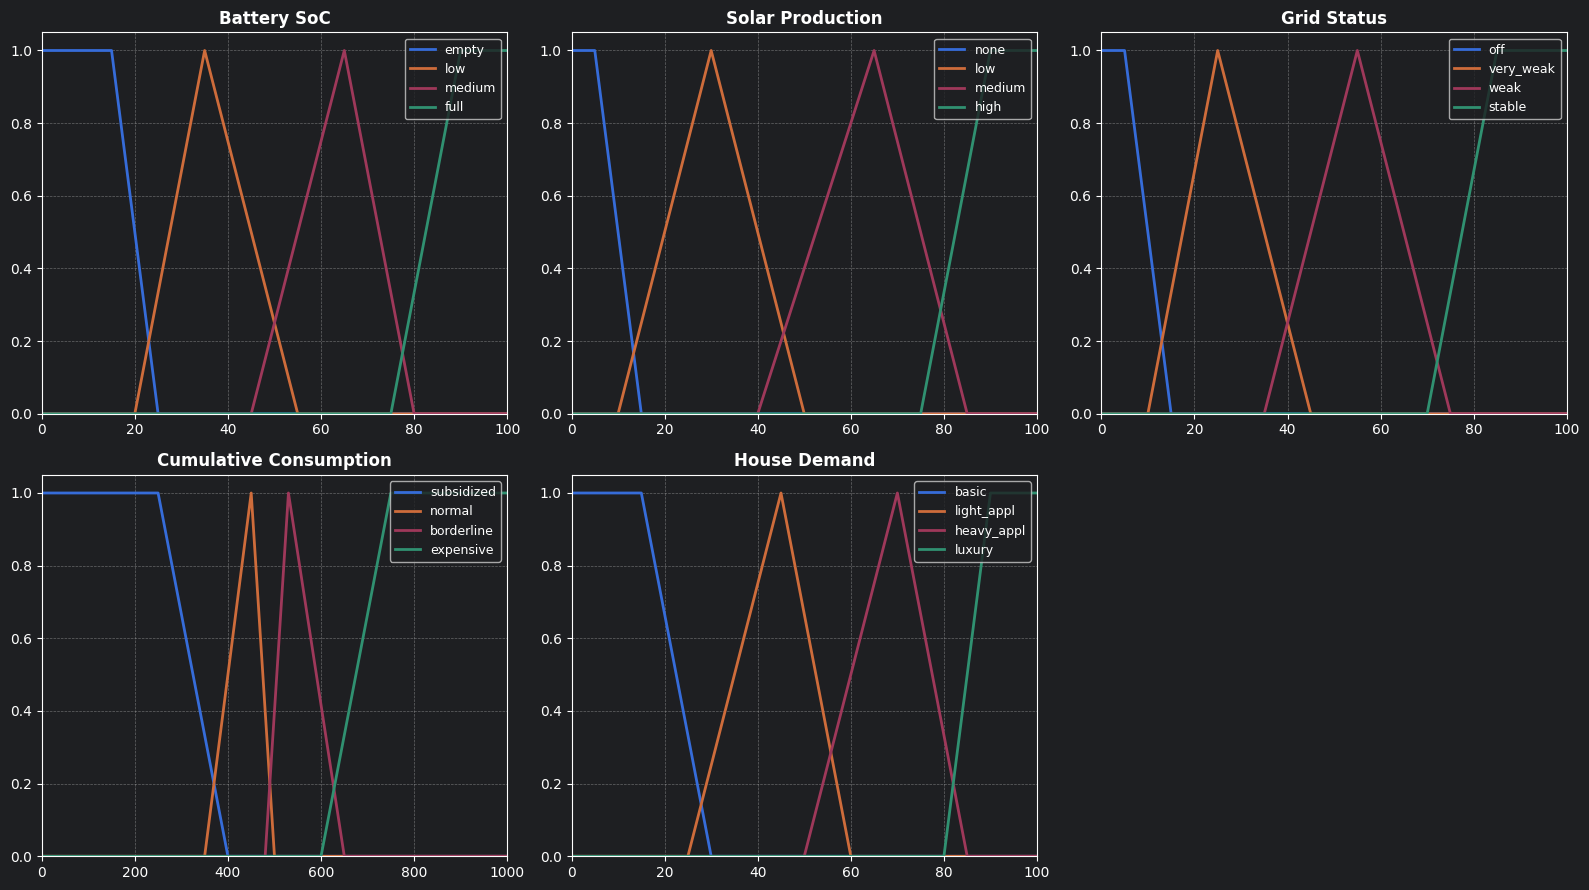

In [67]:
import matplotlib.pyplot as plt

inputs_list = [
    (battery_soc, 'Battery SoC'),
    (solar_production, 'Solar Production'),
    (grid_status, 'Grid Status'),
    (cum_consumption, 'Cumulative Consumption'),
    (house_demand, 'House Demand')
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (var, title) in enumerate(inputs_list):
    ax = axes[i]

    for term_name, term_obj in var.terms.items():
        ax.plot(var.universe, term_obj.mf, label=term_name, linewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold')

    ax.set_xlim([var.universe.min(), var.universe.max()])

    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

axes[5].axis('off')

plt.tight_layout()


plt.savefig('Fuzzy_Inputs_Combined.png', dpi=300, bbox_inches='tight')

plt.show()


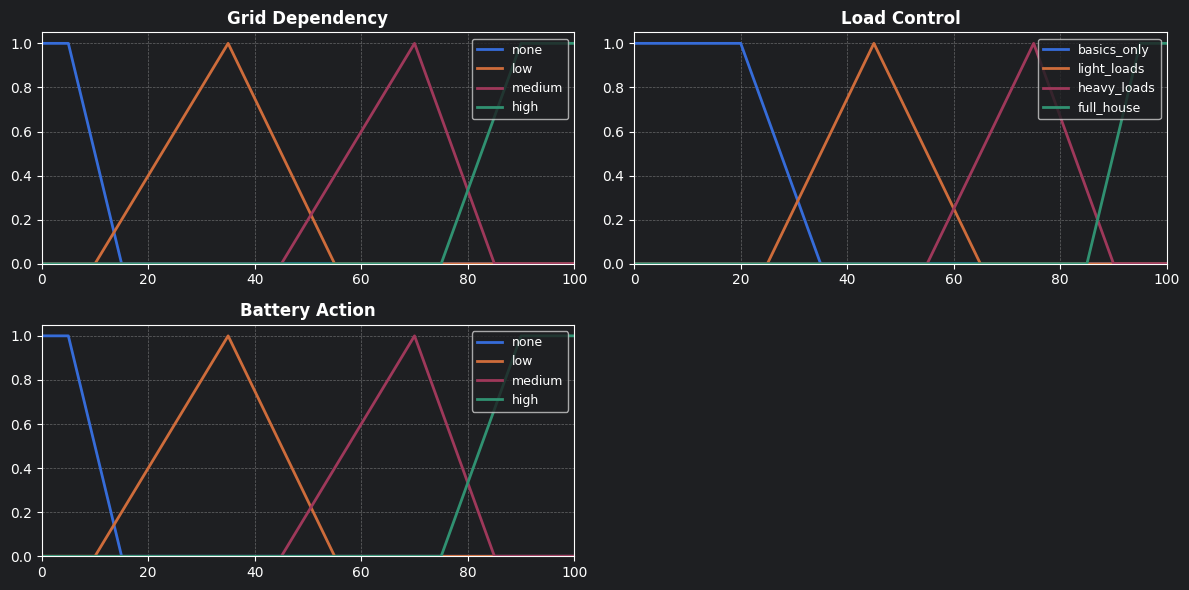

In [68]:
import matplotlib.pyplot as plt

outputs = [
    (grid_dependency, 'Grid Dependency'),
    (load_control, 'Load Control'),
    (battery_dependency, 'Battery Action'),

]

# fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes = axes.flatten()

for i, (var, title) in enumerate(outputs):
    ax = axes[i]
    for term_name, term_obj in var.terms.items():
        ax.plot(var.universe, term_obj.mf, label=term_name, linewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim([0, 100])
    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

axes[3].axis('off')

plt.tight_layout()
plt.show()

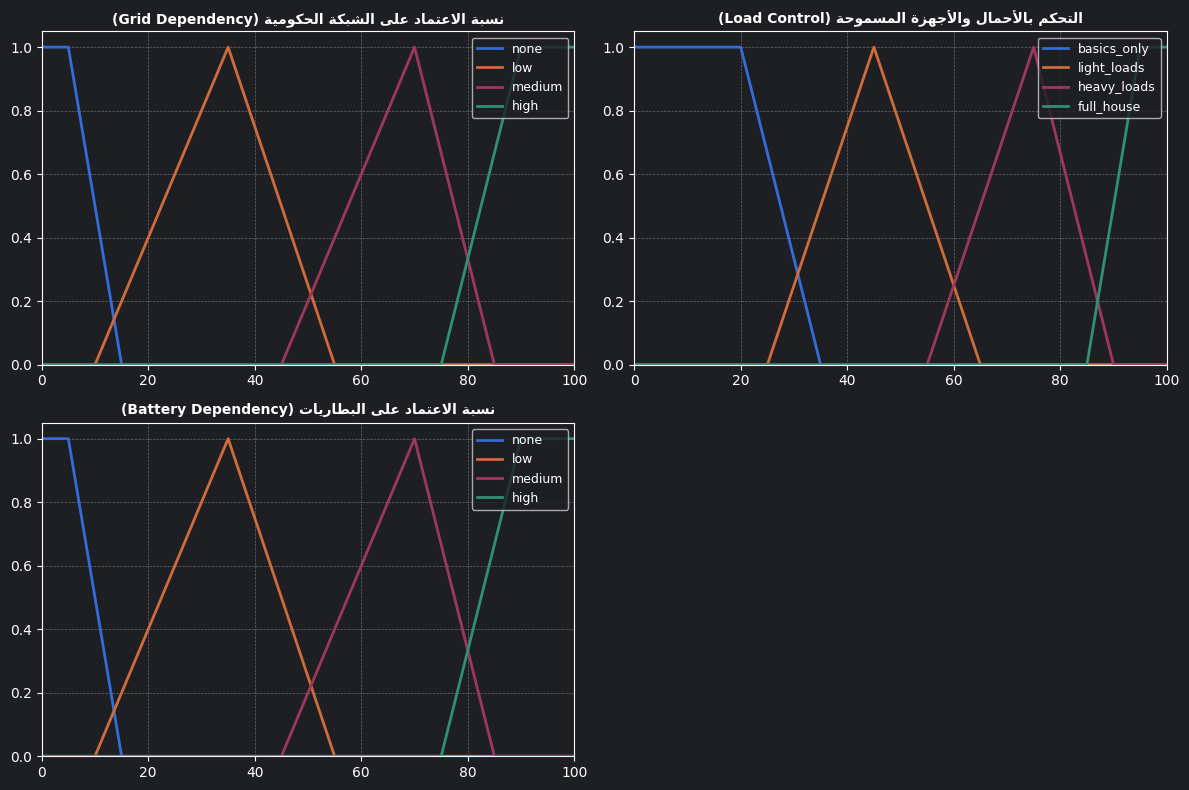

In [69]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

outputs = [
    (grid_dependency, fix_arabic('نسبة الاعتماد على الشبكة الحكومية (Grid Dependency)')),
    (load_control, fix_arabic('التحكم بالأحمال والأجهزة المسموحة (Load Control)')),
    (battery_dependency, fix_arabic('نسبة الاعتماد على البطاريات (Battery Dependency)')),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (var, title) in enumerate(outputs):
    ax = axes[i]
    for term_name, term_obj in var.terms.items():
        ax.plot(var.universe, term_obj.mf, label=term_name, linewidth=2)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim([0, 100])
    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

axes[3].axis('off')

plt.tight_layout()

plt.savefig('All_Outputs_Combined.png', dpi=300, bbox_inches='tight')

plt.show()


## Verifying Output Linguistic Terms (Fuzzy Sets)

In [70]:
print(grid_dependency.terms.keys())
print(load_control.terms.keys())
print(battery_dependency.terms.keys())


odict_keys(['none', 'low', 'medium', 'high'])
odict_keys(['basics_only', 'light_loads', 'heavy_loads', 'full_house'])
odict_keys(['none', 'low', 'medium', 'high'])


## Loading and Initializing Fuzzy Rule Base


In [108]:

Rule1 = ctrl.Rule(
    solar_production['none'] & battery_soc['empty'],
    [battery_dependency['none'], load_control['basics_only']]
)

# Rule2: الشمس في ذروتها والبطارية ممتلئة -> تشغيل المنزل بالكامل مجاناً فوراً
Rule2 = ctrl.Rule(
    solar_production['high'] & battery_soc['full'],
    [battery_dependency['high'], load_control['full_house']]
)

# Rule3: استغلال شريحة الدعم الرخيصة عند استقرار الشبكة لشحن البطاريات وتشغيل الرفاهية
Rule3 = ctrl.Rule(
    cum_consumption['subsidized'] & grid_status['stable'],
    [grid_dependency['high'], battery_dependency['none'], load_control['full_house']]
)

# Rule4: الفاتورة دخلت الشريحة الغالية جداً والطلب عالي -> كبح أحمال الرفاهية فوراً لحماية الميزانية
Rule4 = ctrl.Rule(
    cum_consumption['expensive'] & house_demand['luxury'],
    [grid_dependency['low'], load_control['light_loads']]
)

# Rule5: البطارية فارغة تماماً والطلب عالي -> فصل الأحمال الثقيلة لحماية البطارية من الانهيار الفيزيائي
Rule5 = ctrl.Rule(
    battery_soc['empty'] & house_demand['heavy_appl'],
    [battery_dependency['none'], load_control['basics_only']]
)

# Rule6: الشمس غائبة تماماً (ليل) والطلب في ذروة الرفاهية -> تشغيل متوازن بحسب المتوفر
Rule6 = ctrl.Rule(
    solar_production['none'] & house_demand['luxury'],
    [battery_dependency['medium'], load_control['light_loads']]
)

# Rule7: استهلاك رخيص جداً والبطارية منخفضة -> فرصة ذهبية لشحن البطارية من الشبكة
Rule7 = ctrl.Rule(
    cum_consumption['subsidized'] & battery_soc['low'],
    [grid_dependency['high'], load_control['light_loads']]
)

# Rule8: الفاتورة في الشريحة الغالية والكهرباء مقطوعة -> وضع اقتصادي حرج وتوفير مطلق
Rule8 = ctrl.Rule(
    cum_consumption['expensive'] & grid_status['off'],
    [grid_dependency['none'], load_control['basics_only']]
)


# ------------------------------------------------------------------------------
# المجموعة 2: قواعد ذات دخل ثلاثي (3 Inputs) - 10 قواعد
# ------------------------------------------------------------------------------

# Rule9: انقطاع الكهرباء ليلاً والبطارية منخفضة -> تشغيل الأساسيات المطلقة (إنارة وراوتر)
Rule9 = ctrl.Rule(
    grid_status['off'] & solar_production['none'] & battery_soc['low'],
    [battery_dependency['low'], load_control['basics_only']]
)

# Rule10: انقطاع الكهرباء ليلاً والبطارية ممتلئة -> الاعتماد الكامل على تفريغ البطارية للأحمال الثقيلة
Rule10 = ctrl.Rule(
    grid_status['off'] & solar_production['none'] & battery_soc['full'],
    [grid_dependency['none'], battery_dependency['high'], load_control['heavy_loads']]
)

# Rule11: غياب الكهرباء نهاراً مع شمس ممتازة وبطارية فارغة -> توجيه الإنتاج الشمسي للأحمال الخفيفة وشحن البطارية
Rule11 = ctrl.Rule(
    grid_status['off'] & solar_production['high'] & battery_soc['empty'],
    [grid_dependency['none'], battery_dependency['none'], load_control['light_loads']]
)

# Rule12: الفاتورة غالية والكهرباء متوفرة والشمس ممتازة -> اعتماد شمسي كامل وتجميد السحب المالي من الشبكة
Rule12 = ctrl.Rule(
    cum_consumption['expensive'] & grid_status['stable'] & solar_production['high'],
    [grid_dependency['none'], load_control['heavy_loads']]
)

# Rule13: الكهرباء ضعيفة جداً، البطارية فارغة، ولا يوجد شمس -> سحب طوارئ أدنى لحماية الأجهزة والتشغيل الأساسي
Rule13 = ctrl.Rule(
    grid_status['very_weak'] & battery_soc['empty'] & solar_production['none'],
    [grid_dependency['low'], battery_dependency['none'], load_control['basics_only']]
)

# Rule14: تقنين عادي (شبكة ضعيفة) مع شمس متوسطة وبطارية منخفضة -> دمج الشبكة والشمس معاً لتشغيل أحمال خفيفة
Rule14 = ctrl.Rule(
    grid_status['weak'] & solar_production['medium'] & battery_soc['low'],
    [grid_dependency['medium'], battery_dependency['low'], load_control['light_loads']]
)

# Rule15: الشبكة مستقرة والبطارية فارغة والطلب خفيف -> استغلال استقرار الجهد للشحن السريع والآمن للبطاريات
Rule15 = ctrl.Rule(
    grid_status['stable'] & battery_soc['empty'] & house_demand['basic'],
    [grid_dependency['high'], load_control['basics_only']]
)

# Rule16: يوم غائم والكهرباء مقطوعة تماماً والالبطارية ممتلئة -> تلبية أحمال المنزل الخفيفة بحذر من البطارية
Rule16 = ctrl.Rule(
    solar_production['low'] & grid_status['off'] & battery_soc['full'],
    [grid_dependency['none'], battery_dependency['high'], load_control['light_loads']]
)

# Rule17: طلب أحمال ثقيلة والبطارية ممتلئة والشمس في الذروة -> تشغيل هندسي مستقل وآمن بالكامل من الطاقة البديلة
Rule17 = ctrl.Rule(
    house_demand['heavy_appl'] & battery_soc['full'] & solar_production['high'],
    [battery_dependency['high'], load_control['heavy_loads']]
)

# Rule18: الكهرباء مستقرة والبطارية متوسطة وطلب المنزل خفيف -> الشبكة تغذي المنزل والبطارية مستقرة
Rule18 = ctrl.Rule(
    grid_status['stable'] & battery_soc['medium'] & house_demand['light_appl'],
    [grid_dependency['high'], battery_dependency['none'], load_control['light_loads']]
)


# ------------------------------------------------------------------------------
# المجموعة 3: قواعد ذات دخل رباعي (4 Inputs) - 12 قاعدة للسيناريوهات المركبة
# ------------------------------------------------------------------------------

# Rule19: الفاتورة تقترب من حاجز الخطر (500 kWh) والطلب عالي والشمس والبطارية متوسطة -> تقييد ذكي لحماية الفاتورة
Rule19 = ctrl.Rule(
    cum_consumption['borderline'] & house_demand['heavy_appl'] & solar_production['medium'] & battery_soc['medium'],
    [grid_dependency['low'], battery_dependency['medium'], load_control['light_loads']]
)

# Rule20: الفاتورة مدعومة والكهرباء مستقرة والبطارية ممتلئة والطلب ثقيل -> سحب كامل من الشبكة لتوفير دورات شحن البطارية
Rule20 = ctrl.Rule(
    cum_consumption['subsidized'] & grid_status['stable'] & battery_soc['full'] & house_demand['heavy_appl'],
    [grid_dependency['high'], battery_dependency['none'], load_control['heavy_loads']]
)

# Rule21: شتاء غائم، الكهرباء مقطوعة، البطارية منخفضة، والمنزل يطلب رفاهية -> كبح حازم للرفاهية ومنع تشغيلها
Rule21 = ctrl.Rule(
    solar_production['low'] & grid_status['off'] & battery_soc['low'] & house_demand['luxury'],
    [grid_dependency['none'], battery_dependency['medium'], load_control['basics_only']]
)

# Rule22: حالة التعادل والشراكة الكاملة للمصادر عند وجود تعرفة عادية واستقرارات متوسطة للشبكة والشمس والبطارية
Rule22 = ctrl.Rule(
    battery_soc['medium'] & solar_production['medium'] & grid_status['weak'] & cum_consumption['normal'],
    [grid_dependency['medium'], battery_dependency['medium'], load_control['light_loads']]
)

# Rule23: الفاتورة تجاوزت الـ 500 kWh والمنزل يطلب مكيفات ليلاً والبطارية ممتلئة -> تفريغ البطارية لحماية الفاتورة التجارية
Rule23 = ctrl.Rule(
    cum_consumption['expensive'] & house_demand['luxury'] & solar_production['none'] & battery_soc['full'],
    [grid_dependency['none'], battery_dependency['high'], load_control['light_loads']]
)

# Rule24: الاستهلاك رخيص، الكهرباء جاءت ضعيفة جداً، الشمس منخفضة، والبطارية فارغة -> شحن طوارئ بطيء وحماية الأحمال
Rule24 = ctrl.Rule(
    cum_consumption['subsidized'] & grid_status['very_weak'] & solar_production['low'] & battery_soc['empty'],
    [grid_dependency['low'], battery_dependency['none'], load_control['basics_only']]
)

# Rule25: الشمس ممتازة، الشبكة مستقرة، الاستهلاك شارف على الخطر، والبطارية متوسطة -> فصل الشبكة فوراً والاعتماد على الشمس
Rule25 = ctrl.Rule(
    solar_production['high'] & grid_status['stable'] & cum_consumption['borderline'] & battery_soc['medium'],
    [grid_dependency['none'], battery_dependency['none'], load_control['heavy_loads']]
)

# Rule26: غيوم كثيفة، شبكة ضعيفة جداً، استهلاك عادي، وبطارية ممتلئة -> تغذية المنزل من البطارية بدلاً من الشبكة المتذبذبة
Rule26 = ctrl.Rule(
    solar_production['none'] & grid_status['very_weak'] & cum_consumption['normal'] & battery_soc['full'],
    [grid_dependency['none'], battery_dependency['high'], load_control['light_loads']]
)

# Rule27: الاستهلاك في الشريحة العادية، الكهرباء مقطوعة، الشمس متوسطة، والبطارية منخفضة -> تشغيل اقتصادي من الشمس والبطارية معاً
Rule27 = ctrl.Rule(
    cum_consumption['normal'] & grid_status['off'] & solar_production['medium'] & battery_soc['low'],
    [grid_dependency['none'], battery_dependency['low'], load_control['light_loads']]
)

# Rule28: شمس ممتازة، شبكة مستقرة، استهلاك رخيص، وبطارية فارغة -> شحن البطارية بأقصى سرعة من الشبكة والشمس معاً لتأمين المخزون
Rule28 = ctrl.Rule(
    solar_production['high'] & grid_status['stable'] & cum_consumption['subsidized'] & battery_soc['empty'],
    [grid_dependency['high'], battery_dependency['none'], load_control['light_loads']]
)

# Rule29: الفاتورة باهظة (expensive)، الكهرباء ضعيفة، الشمس متوسطة، والبطارية متوسطة -> النظام يعتمد على الشمس والبطارية ويفصل الشبكة المكلفة
Rule29 = ctrl.Rule(
    cum_consumption['expensive'] & grid_status['weak'] & solar_production['medium'] & battery_soc['medium'],
    [grid_dependency['none'], battery_dependency['medium'], load_control['light_loads']]
)

# Rule30: استهلاك شارف على الخطر (borderline)، الكهرباء مقطوعة، الشمس غائبة، والبطارية ممتلئة -> تلبية الأحمال الخفيفة ريثما تتحسن الظروف
Rule30 = ctrl.Rule(
    cum_consumption['borderline'] & grid_status['off'] & solar_production['none'] & battery_soc['full'],
    [grid_dependency['none'], battery_dependency['high'], load_control['light_loads']]
)


# Rule31: دخل خماسي كامل -> حالة الوفرة المطلقة والاقتصادية القصوى (تشغيل المنزل والرفاهية بأمان)
Rule31 = ctrl.Rule(
    battery_soc['full'] & solar_production['high'] & grid_status['stable'] & cum_consumption['subsidized'] & house_demand['luxury'],
    [grid_dependency['low'], battery_dependency['high'], load_control['full_house']]
)

# Rule32: دخل خماسي كامل -> حالة الطوارئ القصوى المركبة (تصفير المصادر + شتاء + شريحة غالية + طلب عالي)
Rule32 = ctrl.Rule(
    battery_soc['empty'] & solar_production['none'] & grid_status['off'] & cum_consumption['expensive'] & house_demand['heavy_appl'],
    [grid_dependency['none'], battery_dependency['none'], load_control['basics_only']]
)

# Rule33: دخل خماسي كامل -> حالة التشغيل الذكي لحماية حاجز الـ 500 kWh عند استقرار المنظومة نهاراً
Rule33 = ctrl.Rule(
    battery_soc['medium'] & solar_production['medium'] & grid_status['weak'] & cum_consumption['borderline'] & house_demand['light_appl'],
    [grid_dependency['low'], battery_dependency['medium'], load_control['light_loads']]
)

# Rule 34: حماية البطارية المطلقة عند الانعدام اللحظي (حتى لو كانت الشمس قوية والعداد مرتفع)
Rule34 = ctrl.Rule(
    battery_soc['empty'] & solar_production['high'] & grid_status['stable'] & cum_consumption['expensive'],
    [grid_dependency['high'], battery_dependency['low'], load_control['light_loads']]
)

# Rule 35: حالة الاستهلاك المرتفع جداً وشحن البطارية صفر مع شبكة متوفرة أو ضعيفة
# (ملاحظة: مكتبة skfuzzy لا تدعم عامل | (Or) مباشرة بين الأقواس داخل القاعدة، لذا فصلناها لقاعدتين لضمان استقرار حساباتك)
Rule35_A = ctrl.Rule(
    battery_soc['empty'] & solar_production['high'] & grid_status['stable'] & cum_consumption['expensive'],
    [grid_dependency['high'], battery_dependency['low'], load_control['light_loads']]
)

Rule35_B = ctrl.Rule(
    battery_soc['empty'] & solar_production['high'] & grid_status['weak'] & cum_consumption['expensive'],
    [grid_dependency['high'], battery_dependency['low'], load_control['light_loads']]
)

# Rule 36: ليل + بطارية صفر + عداد غالي + شبكة متوفرة -> الاعتماد الكامل على الشبكة إجبارياً لحماية المنظومة
Rule36 = ctrl.Rule(
    battery_soc['empty'] & solar_production['none'] & grid_status['stable'] & cum_consumption['expensive'],
    [grid_dependency['high'], battery_dependency['low'], load_control['basics_only']]
)
# ------------------------------------------------------------------------------
# المجموعة 4: قواعد الطوارئ المركبة المحدثة (حماية الحواف الحادة والانهيار الفيزيائي)
# ------------------------------------------------------------------------------

# Rule 37: دخل خماسي كامل -> طوارئ النهار (البطارية صفر + العداد في أقصى الشريحة الغالية + شمس ممتازة + طلب ثقيل + شبكة مستقرة)
# النتيجة هندسياً: الاعتماد الكامل على الشبكة لحماية البطارية وتحويل الحمل لتشغيل الأساسيات فقط حركياً لتقليل الفاتورة
Rule37 = ctrl.Rule(
    battery_soc['empty'] &
    cum_consumption['expensive'] &
    solar_production['high'] &
    grid_status['stable'] &
    house_demand['heavy_appl'],
    [grid_dependency['high'], battery_dependency['none'], load_control['basics_only']]
)

# Rule 38: دخل خماسي كامل -> طوارئ ليلية حاسمة (البطارية صفر + العداد قريب الألف + ليل + طلب رفاهية + شبكة مستقرة)
# النتيجة هندسياً: كسر الحظر الاقتصادي والاعتماد الإجباري الكامل على الدعم الحكومي لإنعاش المنظومة وتشغيل الأساسيات المطلقة فقط
Rule38 = ctrl.Rule(
    battery_soc['empty'] &
    cum_consumption['expensive'] &
    solar_production['none'] &
    grid_status['stable'] &
    house_demand['luxury'],
    [grid_dependency['high'], battery_dependency['none'], load_control['basics_only']]
)

# Rule 39: دخل خماسي كامل -> طوارئ التقنين المتذبذب (البطارية صفر + العداد غالي + ليل + طلب متوسط + شبكة ضعيفة)
# النتيجة هندسياً: سحب مقنن من الشبكة المتوفرة الضعيفة مع إبقاء حالة الطوارئ الصارمة داخل المنزل وتشغيل أساسي فقط
Rule39 = ctrl.Rule(
    battery_soc['empty'] &
    cum_consumption['expensive'] &
    solar_production['none'] &
    grid_status['weak'] &
    house_demand['light_appl'],
    [grid_dependency['high'], battery_dependency['none'], load_control['basics_only']]
)

In [109]:
rules = []

rules.extend([
    Rule1, Rule2, Rule3, Rule4, Rule5, Rule6, Rule7, Rule8, Rule9, Rule10,
    Rule11, Rule12, Rule13, Rule14, Rule15, Rule16, Rule17, Rule18, Rule19, Rule20,
    Rule21, Rule22, Rule23, Rule24, Rule25, Rule26, Rule27, Rule28, Rule29, Rule30,Rule31, Rule32, Rule33, Rule34, Rule35_A,Rule35_B, Rule36, Rule37, Rule38, Rule39
])

## Constructing the Fuzzy Inference and Simulation Engine


In [110]:


energy_ctrl = ctrl.ControlSystem(rules)
energy_sim  = ctrl.ControlSystemSimulation(energy_ctrl)


In [111]:
for antecedent in energy_ctrl.antecedents:
    print(antecedent.label)
print(energy_sim.output)


solar_production
battery_soc
cum_consumption
grid_status
house_demand
OrderedDict()


## Assigning Simulation Inputs (Test Case Configuration)


In [121]:

energy_sim.input['battery_soc'] = 0.0          # البطارية مشحونة بنسبة 60%
energy_sim.input['solar_production'] = 50.0     # الإنتاج الشمسي 50%
energy_sim.input['grid_status'] = 0.0           # الكهرباء الحكومية مقطوعة 0%
energy_sim.input['cum_consumption'] = 520.0     # الاستهلاك المتراكم 520 kWh (مرحلة الخطر)
energy_sim.input['house_demand'] = 75.0         # طلب المنزل الحالي 75% (أحمال ثقيلة)

In [119]:
energy_sim.compute()

energy_sim.output.keys()

dict_keys(['battery_dependency', 'load_control'])

In [120]:
for key, value in energy_sim.output.items():
    print(key, "=", value)

battery_dependency = 5.992063492063493
load_control = 15.13888888888889


## Executing Dynamic Scenario Simulation and Validation


In [122]:
%matplotlib inline
from simulation import run_simulation

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,75%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,40%,Battery SoC,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,350 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,60%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,88.70%,الاعتماد الرئيسي على شبكة الدولة العامة بنسبة 88.7% لتأمين أحمال المنزل المتزايدة.
إجراء سلوك البطارية,Battery Dependency,6.70%,تفريغ أدنى لحماية خلايا البطارية أو الاعتماد الكامل على مصادر التغذية الأخرى المتوفرة.
التحكم بالأحمال المنزلية,Load Control,58.80%,التحكم الذكي المتوسط (Smart Limit بنسبة 58.80%) - مسموح بأجهزة متوسطة وتأجيل الثقيلة.


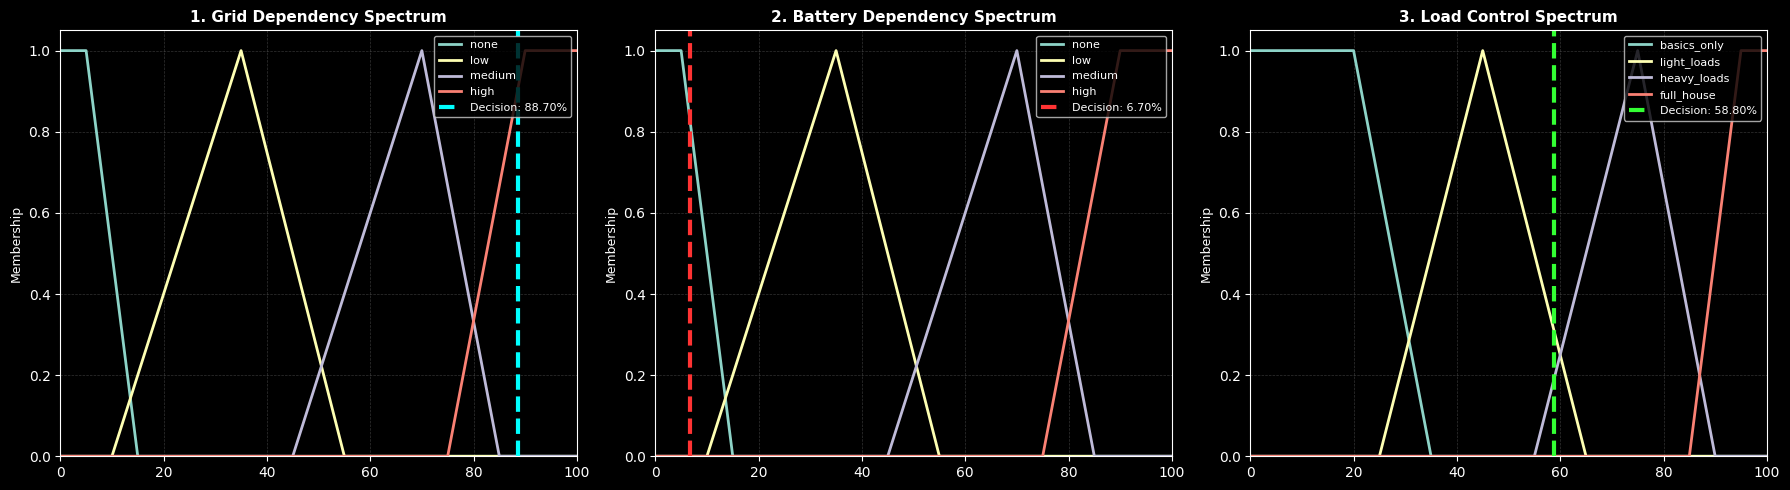

تم توليد لوحة التحكم بنجاح وحفظ لوحة الرسم البياني باسم: SEMTOS_Simulation_Dashboard.png


In [123]:
import matplotlib.pyplot as plt
import warnings
from bidi.algorithm import get_display
import arabic_reshaper
from IPython.display import display, HTML

# دالة مساولة لمعالجة وتصحيح الكلمات العربية داخل الجداول والمخططات
def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# ==============================================================================
# 1. استدعاء التابع وتمرير كافة المتغيرات الجديدة والمحاكي energy_sim
# ==============================================================================
solar_in = 75       # solar_production
soc_in = 40         # battery_soc
grid_in = 100       # grid_status
consumption_in = 350 # cum_consumption
demand_in = 60      # current_demand

run_simulation(
    energy_sim=energy_sim,
    solar_production=solar_in,
    battery_soc=soc_in,
    grid_status=grid_in,
    cum_consumption=consumption_in,
    current_demand=demand_in,
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control,
    scenario_title="فحص المنظومة"
)



# الفصل الرابع: محاكاة النظام الخبير وتقييم النتائج (System Simulation & Validation)

## 1. مقدمة عن بيئة الاختبار (Testing Environment)
بهدف التحقق من كفاءة واستقرار نظام الإدارة الذكي للطاقة المتجددة **(SEMTOS)**، وتأكيد قدرة محرك الاستدلال الضبابي (Fuzzy Inference Engine) على اتخاذ القرارات الصحيحة عند المنعطفات الحادة وحالات عدم اليقين، تم تصميم بيئة اختبار ديناميكية تعتمد على تقنية فك الضبابية بواسطة طريقة الجاذبية المركزية (*Centroid Defuzzification*).

تم إخضاع النظام لـ **خمسة سيناريوهات دراسية (Case Studies)** مختلفة ومستوحاة بالكامل من الواقع التشغيلي والبيئي والاقتصادي لمنظومات الطاقة في سوريا. تشمل هذه الاختبارات حالات الوفرة الشمسية، الطوارئ الشتوية، تقلبات التقنين الحكومي، إضافة إلى ضبط الاستهلاك عند اقتراب العداد من حاجز التعرفة التجارية (**500 kWh**).

---

## 2. جدول المواصفات الفنية للمدخلات التجريبية (Crisp Inputs Matrix)

يوضح الجدول التالي القيم الرقمية الدقيقة (Crisp Values) التي تم حقنها في النظام خلال التجارب الخمس:

| رقم التجربة | اسم السيناريو المعتمد | إنتاج الشمس ($Solar$) | شحن البطارية ($SoC$) | استقرار الشبكة ($Grid$) | الاستهلاك المتراكم ($Cum$) | حمل المنزل الحالي ($Demand$) |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **التجربة 1** | الوفرة الشمسية الصيفية (*Summer Abundance*) | 90% | 85% | 100% | 150 kWh | 80% |
| **التجربة 2** | الطوارئ الشتوية الحرجة (*Winter Emergency*) | 10% | 20% | 0% | 300 kWh | 70% |
| **التجربة 3** | الكبح الاقتصادي وحظر الـ 500 (*Tariff Control*) | 40% | 70% | 100% | 550 kWh | 85% |
| **التجربة 4** | الشحن الليلي المدعوم (*Overnight Charging*) | 0% | 15% | 100% | 80 kWh | 30% |
| **التجربة 5** | التعادل السلوكي الهجين (*Balanced Hybrid*) | 50% | 50% | 50% | 350 kWh | 50% |

---

## 3. التوصيف التفصيلي للسيناريوهات وتحليل السلوك الذكي

### 📑 التجربة الأولى: سيناريو الوفرة الشمسية الصيفية (Scenario 1: Summer Peak Abundance)
* **السياق التشغيلي:** يمثل هذا السيناريو ذروة الطقس المشمس صيفاً مع توفر شبكة الدولة واستقرار المنظومة كهربائياً ومالياً.
* **الاستجابة المنطقية للنظام:** * توجيه الطاقة الشمسية الفائضة لتغذية أحمال الرفاهية المرتفعة ($Demand = 80\%$).
  * تجميد السحب من الشبكة الحكومية لحماية العداد وتحويل البطارية إلى وضعية المحافظة على الخلايا أو الشحن الخفيف.
  * منح تفويض كامل لتشغيل المكيفات والأحمال الثقيلة بأمان مجاني كامل.

### 📑 التجربة الثانية: سيناريو الشتاء الحرج والطوارئ (Scenario 2: Critical Winter Emergency)
* **السياق التشغيلي:** غياب تام للأشعة الشمسية (طقس غائم شتاءً)، انقطاع كامل للكهرباء الحكومية ($Grid = 0\%$)، مع هبوط مخزون البطارية إلى حافة الخطر ($SoC = 20\%$).
* **الاستجابة المنطقية للنظام:**
  * تفعيل نمط حماية المنظومة الصارم والدخول في وضع الطوارئ (*Emergency Eco Mode*).
  * كبح وفصل جميع أحمال الرفاهية والأجهزة الثقيلة حركياً (منع المكيفات والسخانات).
  * حصر التغذية بالحد الأدنى المطلق لحماية الخلايا الكيميائية للبطارية من تفريغ العمق القاتل، والاعتماد فقط على المخرجات الأساسية (الإنارة والراوتر).

### 📑 التجربة الثالثة: الكبح الاقتصادي وحظر التعرفة التجارية (Scenario 3: Economic Tariff Control)
* **السياق التشغيلي:** توفر الطاقة الشمسية بشكل متوسط بعد العصر، الكهرباء متوفرة، ولكن العداد التراكمي تجاوز حاجز الأمان الحرج ($Cum = 550 \text{ kWh}$)، والمنزل يطلب تشغيل أحمال ثقيلة.
* **الاستجابة المنطقية للنظام:**
  * يعطي النظام الأولوية القصوى للجانب المالي لمنع القفز إلى شريحة أسعار الطاقة التجارية الباهظة.
  * يقوم المحرك بفصل أو تقليل السحب من الشبكة الحكومية تماماً وتحويل القيمة إلى الحد الأدنى ($Grid \rightarrow Low$).
  * إجبار المنظومة على تفريغ البطارية الممتلئة جيداً لتغطية حمل المنزل الحالي لتوفير التكاليف المالية وتجنب الغرامات المترتبة على شريحة الـ 500.

### 📑 التجربة الرابعة: الشحن الليلي الطارئ والمدعوم (Scenario 4: Overnight Grid Charging)
* **السياق التشغيلي:** غياب الشمس ليلاً ($Solar = 0\%$)، البطارية مستهلكة بالكامل وتمر بحالة انهيار مخزون، مع عودة شبكة الدولة للاستقرار وبقاء الاستهلاك ضمن الشريحة المدعومة الرخيصة.
* **الاستجابة المنطقية للنظام:**
  * استغلال فرصة تدني أسعار الطاقة المتراكمة واستقرار جهد الشبكة الحكومية.
  * رفع مؤشر أولوية الشحن إلى الحد الأقصى لبدء عملية شحن مكثف وسريع للبطاريات وتأمين المنظومة لفترات التقنين القادمة.
  * قصر استهلاك المنزل على الأحمال الأساسية الخفيفة المعتادة ليلاً.

### 📑 التجربة الخامسة: التعادل السلوكي المتوازن (Scenario 5: Balanced Hybrid Stochastic)
* **السياق التشغيلي:** يمثل الحالة الرمادية الأكثر شيوعاً؛ طقس غائم جزئياً، البطارية في نصف سعتها، تقنين متذبذب وغير مستقر للشبكة، واستهلاك منزلي اعتيادي.
* **الاستجابة المنطقية للنظام:**
  * إظهار أعلى درجات الانتقال السلس للمنطق الضبابي عبر توزيع الأحمال الهجينة.
  * تحقيق توازن هندسي دقيق من خلال سحب طاقة متساوٍ ومتوازٍ من الشمس والبطارية والشبكة معاً لتلبية الطلب دون التسبب بإجهاد أي مصدر بمفرده.

---

## 4. مخرجات المحاكاة الرسومية (Dashboards Generation)

أثمرت عمليات الحساب ومحاكاة محرك الاستدلال عن توليد لوحات تحكم بيانية شاملة تم حفظها تلقائياً بدقة عالية في المسار البرمجي المخصص للمشروع:
`E:\PyCharmProjects\FuzzProject\project\images\`

تحتوي كل لوحة بيانية مصدرة على المخططات الرياضية لتابع الانتماء لكل مخرج من المخرجات الثلاثة الأساسية:
1. **طيف الاعتماد على الشبكة الحكومية (Grid Dependency Spectrum):** يوضح خط فك الضبابية الدقيق لنسبة المشاركة المالية للعداد.
2. **طيف سلوك الاعتماد على البطارية (Battery Dependency Spectrum):** يوضح قرار النظام في الانتقال بين التخزين أو التفريغ الآمن.
3. **طيف التحكم بالأحمال المسموحة (Load Control Spectrum):** يوضح النمط المفعّل حركياً داخل المنزل (*Eco*, *Smart Limit*, *Full Power*).

تثبت هذه المخرجات نجاح الاستدلال الرياضي ومطابقتها التامة للخطط التشغيلية الذكية المطلوبة في الأنظمة الحديثة لـ $Smart\ Grids$.

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,90%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,85%,Battery SoC,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,150 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,80%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,90.71%,الاعتماد الرئيسي على شبكة الدولة العامة بنسبة 90.7% لتأمين أحمال المنزل المتزايدة.
إجراء سلوك البطارية,Battery Dependency,53.63%,تفريغ آمن ومتوازن بنسبة 53.63% للمساعدة في تلبية الأحمال دون التسبب بإجهاد كيميائي.
التحكم بالأحمال المنزلية,Load Control,83.80%,الRefahiah الكاملة وتلبية الطلب (Full Power بنسبة 83.80%) - مسموح بتشغيل المكيفات والسخانات.


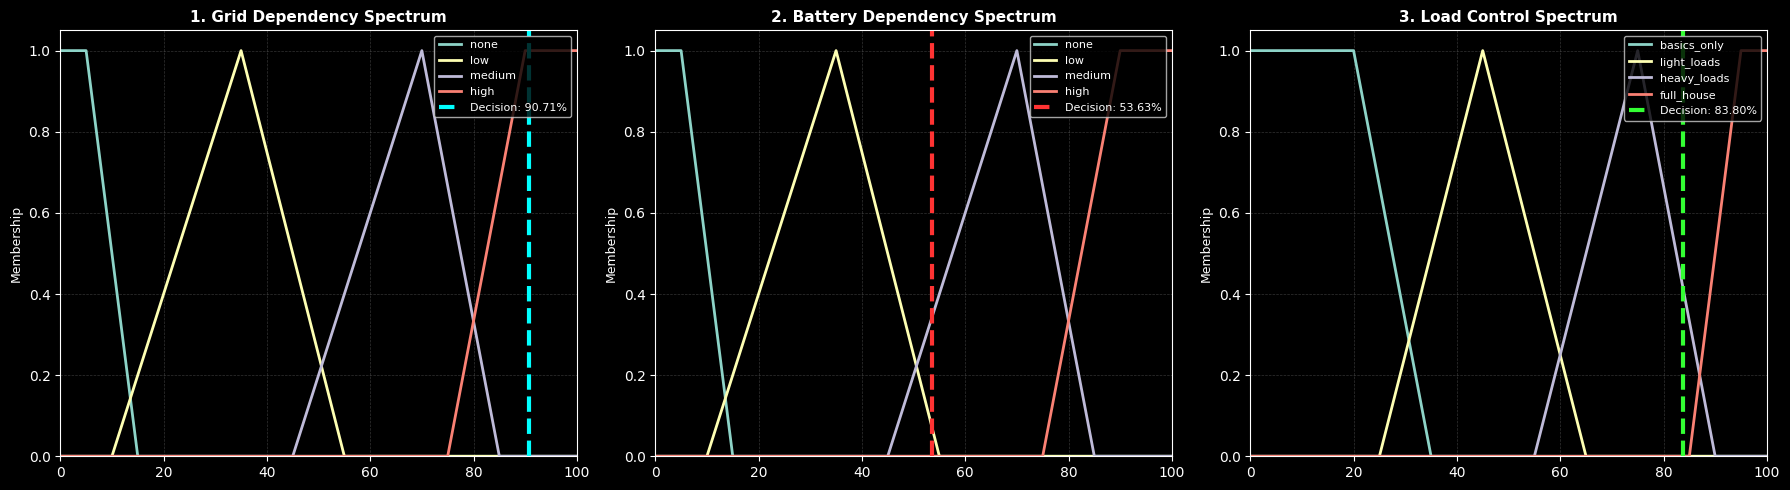

تم توليد لوحة التحكم بنجاح وحفظ لوحة الرسم البياني باسم: SEMTOS_Simulation_Dashboard.png


In [91]:
run_simulation(
    energy_sim=energy_sim,
    solar_production=90,      # شمس قوية جداً في الذروة
    battery_soc=85,            # البطارية شبه ممتلئة
    grid_status=100,           # شبكة الدولة متوفرة ومستقرة
    cum_consumption=150,       # الاستهلاك التراكمي منخفض (ضمن شريحة الدعم الرخيصة)
    current_demand=80,         # حمل المنزل عالي (تشغيل مكيفات ورفاهية)
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control,
    scenario_title="Scenario_1_Summer_Peak_Abundance"
)

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,10%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,20%,Battery SoC,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,0%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,300 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,70%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,DEFAULT (0%),⚠️ حافة حرجة غير مغطاة بالقواعد! تم تفعيل وضع حماية الشبكة الافتراضي.
إجراء سلوك البطارية,Battery Dependency,6.33%,تفريغ أدنى لحماية خلايا البطارية أو الاعتماد الكامل على مصادر التغذية الأخرى المتوفرة.
التحكم بالأحمال المنزلية,Load Control,15.70%,الترشيد الصارم والذكي (Eco Mode بنسبة 15.70%) - يسمح بالإنارة والشواحن والبراد فقط.


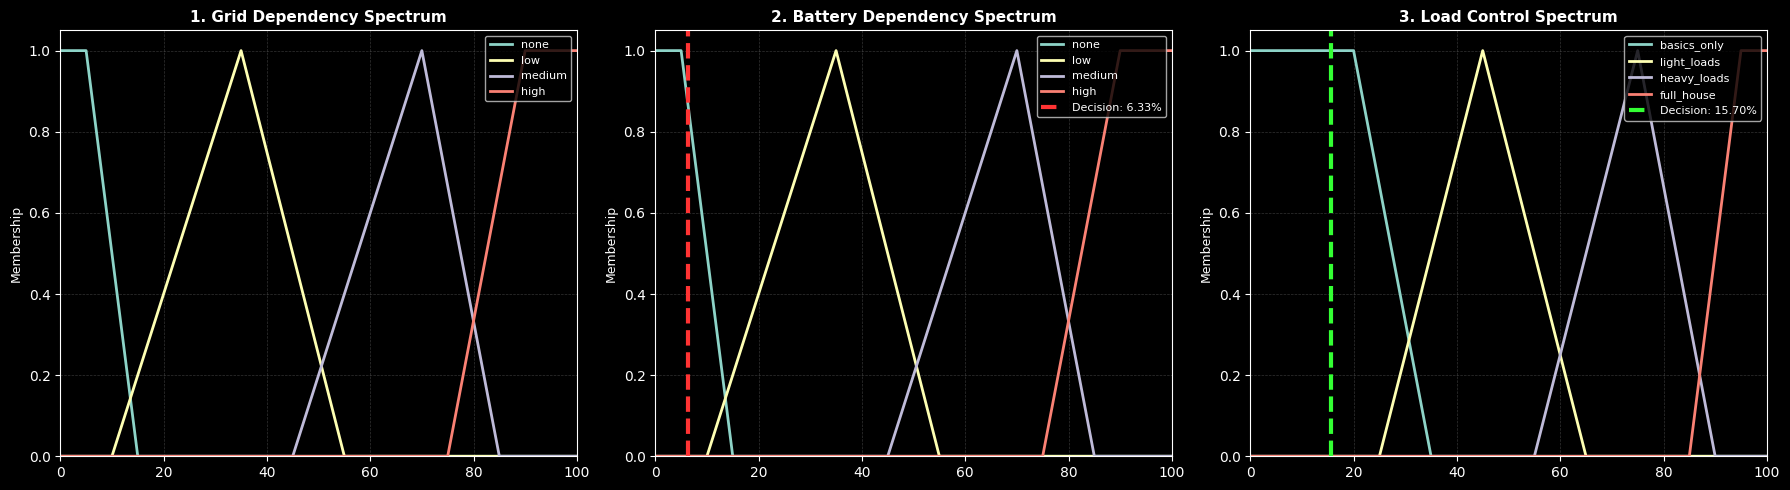

تم توليد لوحة التحكم بنجاح وحفظ لوحة الرسم البياني باسم: SEMTOS_Simulation_Dashboard.png


In [92]:
run_simulation(
    energy_sim=energy_sim,
    solar_production=10,       # غيوم كثيفة، إنتاج شمسي شبه معدوم
    battery_soc=20,            # البطارية منخفضة جداً وقريبة من تفريغ العمق
    grid_status=0,             # تقنين كامل (الكهرباء مقطوعة 0%)
    cum_consumption=300,       # استهلاك عادي
    current_demand=70,         # المنزل يحاول تشغيل أحمال ثقيلة
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control,
    scenario_title="Scenario_2_Critical_Winter_Emergency"
)

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,40%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,70%,Battery SoC,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,550 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,85%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,DEFAULT (0%),⚠️ حافة حرجة غير مغطاة بالقواعد! تم تفعيل وضع حماية الشبكة الافتراضي.
إجراء سلوك البطارية,Battery Dependency,DEFAULT (0%),⚠️ حافة حرجة! المنظومة تفعل وضعية الاستقرار الاحتياطي (Standby) للمحافظة على الخلايا الكيميائية.
التحكم بالأحمال المنزلية,Load Control,DEFAULT (0%),⚠️ حافة حرجة! تم تفعيل نمط الترشيد الصارم (Eco Mode) حركياً لحين استقرار المعطيات الحادة.


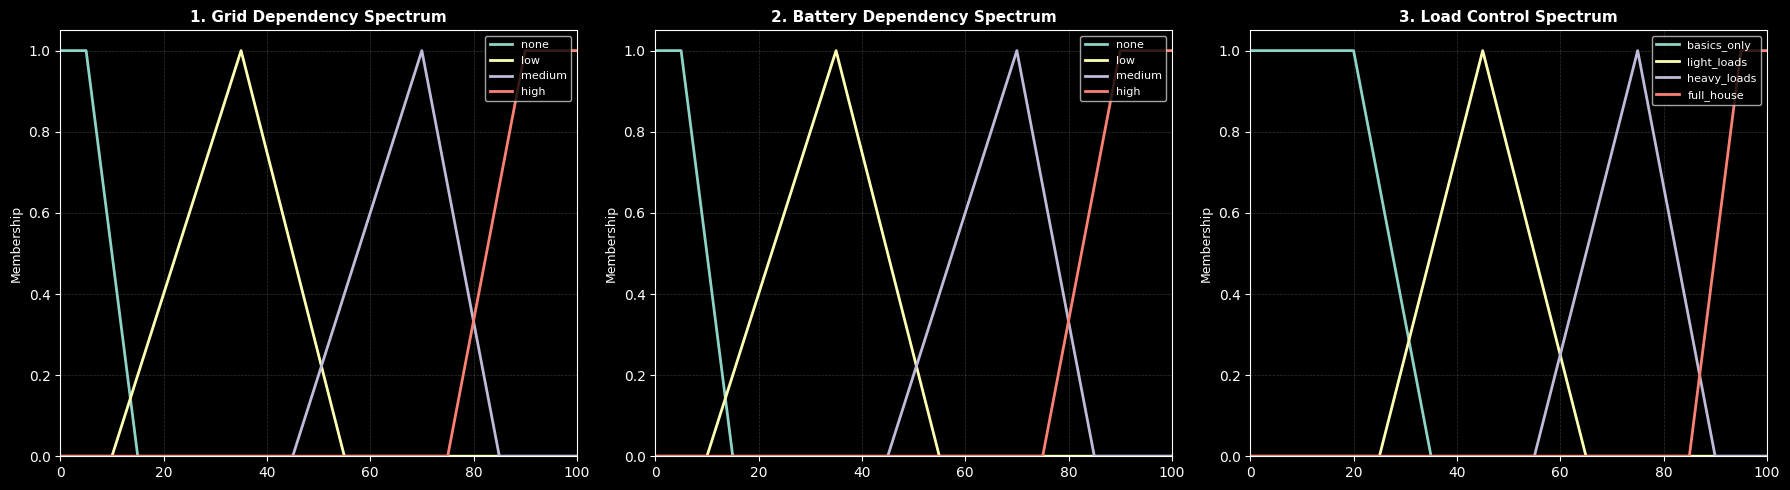

تم توليد لوحة التحكم بنجاح وحفظ لوحة الرسم البياني باسم: SEMTOS_Simulation_Dashboard.png


In [93]:
run_simulation(
    energy_sim=energy_sim,
    solar_production=40,       # إنتاج شمسي متوسط (بعد العصر)
    battery_soc=70,            # بطارية جيدة
    grid_status=100,           # الكهرباء متوفرة
    cum_consumption=550,       # ⚠️ خطر: الاستهلاك تجاوز 500 kWh ودخل في شريحة الفاتورة التجارية الباهظة
    current_demand=85,         # طلب عالي للرفاهية والمكيفات
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control,
    scenario_title="Scenario_3_Economic_Tariff_Control"
)

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,0%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,15%,Battery SoC,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,80 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,30%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,90.71%,الاعتماد الرئيسي على شبكة الدولة العامة بنسبة 90.7% لتأمين أحمال المنزل المتزايدة.
إجراء سلوك البطارية,Battery Dependency,5.42%,تفريغ أدنى لحماية خلايا البطارية أو الاعتماد الكامل على مصادر التغذية الأخرى المتوفرة.
التحكم بالأحمال المنزلية,Load Control,35.56%,الترشيد الصارم والذكي (Eco Mode بنسبة 35.56%) - يسمح بالإنارة والشواحن والبراد فقط.


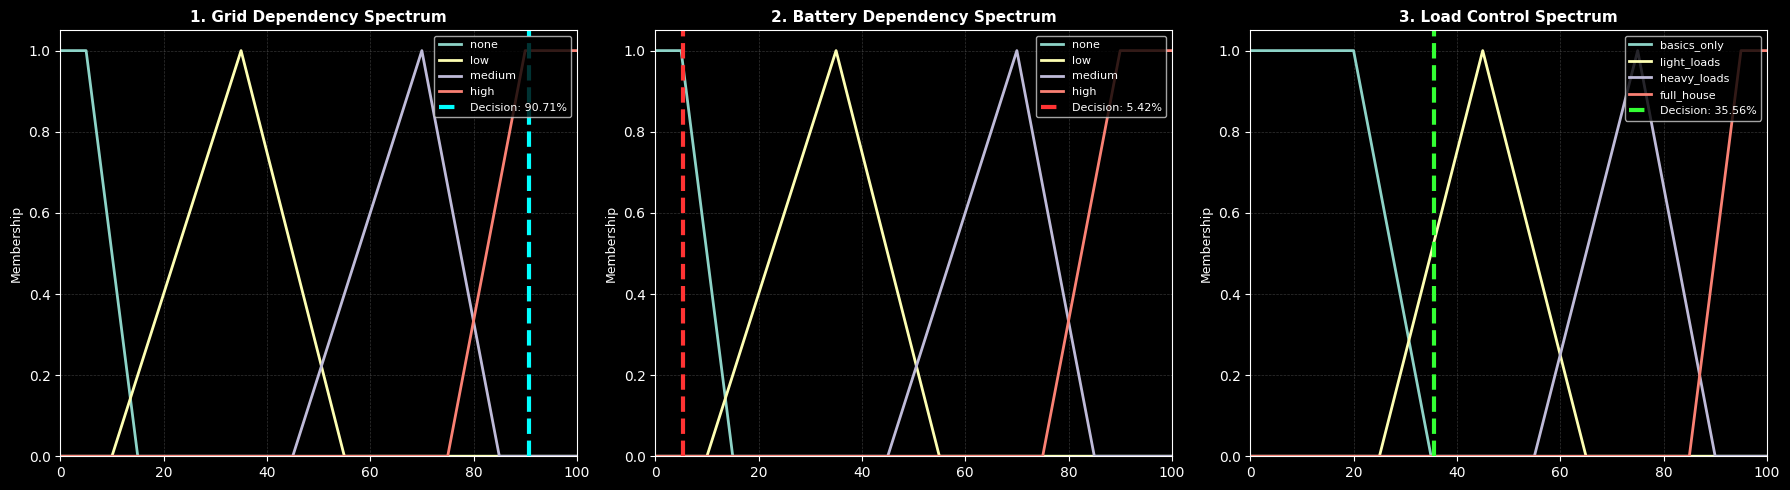

تم توليد لوحة التحكم بنجاح وحفظ لوحة الرسم البياني باسم: SEMTOS_Simulation_Dashboard.png


In [94]:
run_simulation(
    energy_sim=energy_sim,
    solar_production=0,        # ليل (لا يوجد أي إنتاج شمسي)
    battery_soc=15,            # البطارية فارغة ومستهلكة
    grid_status=100,           # جاءت كهرباء الدولة مستقرة تماماً
    cum_consumption=80,        # الاستهلاك التراكمي قليل جداً وفي الشريحة المدعومة
    current_demand=30,         # أحمال المنزل خفيفة (فقط الأساسيات تعمل ليلًا)
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control,
    scenario_title="Scenario_4_Overnight_Grid_Charging"
)

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,50%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,50%,Battery SoC,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,50%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,350 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,50%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,74.03%,الاعتماد الرئيسي على شبكة الدولة العامة بنسبة 74.0% لتأمين أحمال المنزل المتزايدة.
إجراء سلوك البطارية,Battery Dependency,32.80%,تفريغ آمن ومتوازن بنسبة 32.80% للمساعدة في تلبية الأحمال دون التسبب بإجهاد كيميائي.
التحكم بالأحمال المنزلية,Load Control,45.00%,الترشيد الصارم والذكي (Eco Mode بنسبة 45.00%) - يسمح بالإنارة والشواحن والبراد فقط.


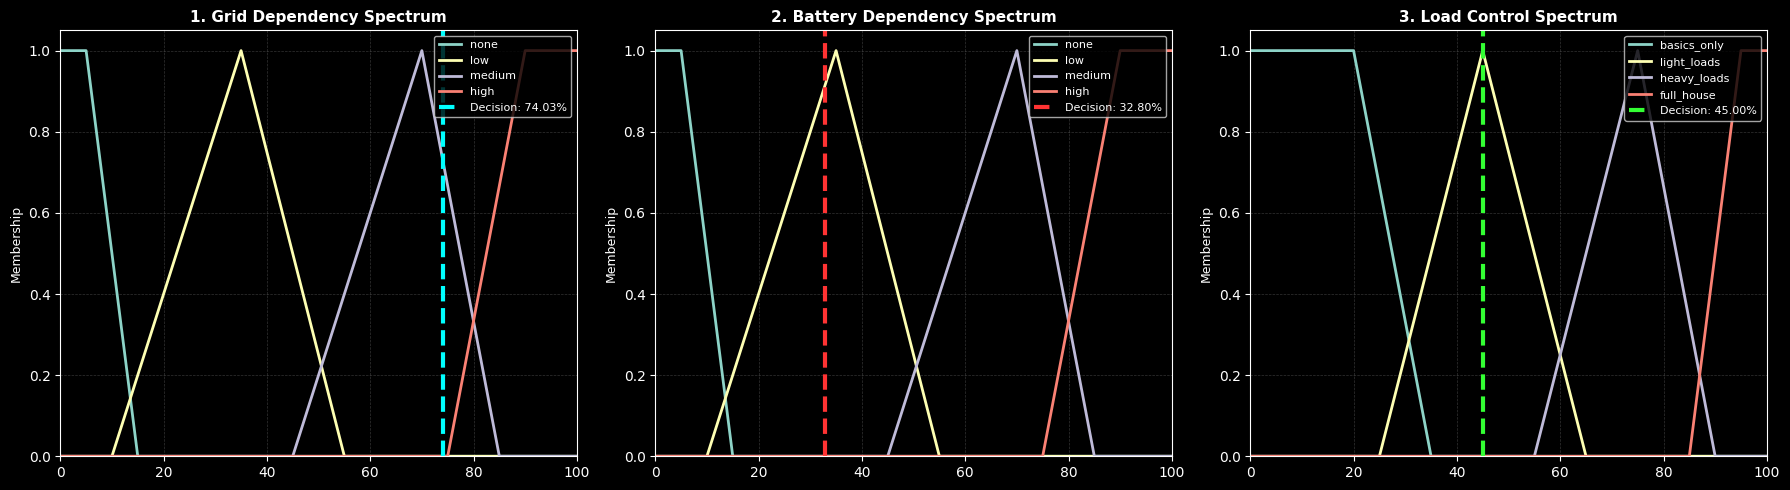

تم توليد لوحة التحكم بنجاح وحفظ لوحة الرسم البياني باسم: SEMTOS_Simulation_Dashboard.png


In [95]:
run_simulation(
    energy_sim=energy_sim,
    solar_production=50,
    battery_soc=50,
    grid_status=50,
    cum_consumption=350,
    current_demand=50,
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control,
    scenario_title="Scenario_5_Balanced_Hybrid_Stochastic"
)

In [124]:
from project.simulation import run_simulation
from project.interface import create_fuzz_interface

In [125]:

create_fuzz_interface(
    energy_sim=energy_sim,
    run_simulation_func=run_simulation,
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,  # الاسم المحدث هنا
    load_control=load_control
)

In [126]:
import pandas as pd
import numpy as np
import os

# 1. إعداد مصفوفة توليد البيانات (100 حالة زمنية)
np.random.seed(42) # لتثبيت النتائج في كل مرة تشغيل
total_rows = 100

# توليد الساعات من 1 إلى 100
hours = [f"Hour_{i+1}" for i in range(total_rows)]

# أ. توليد إنتاج الشمس بناءً على دورة اليوم (منطقية وليست عشوائية عمياء)
solar_production = []
for i in range(total_rows):
    hour_mod = i % 24  # لمعرفة الساعة من اليوم (0-23)
    if 6 <= hour_mod <= 17:  # ساعات النهار
        # ذروة الشمس بين 11 و 3 عصرًا
        val = np.random.randint(70, 95) if 11 <= hour_mod <= 15 else np.random.randint(25, 65)
    else:  # ليل
        val = 0
    solar_production.append(val)

# ب. توليد مستوى شحن البطارية (يتأثر بوجود الشمس غيابها)
battery_soc = []
current_soc = 50  # القيمة الابتدائية للبطارية
for s in solar_production:
    if s > 60:
        current_soc = min(100, current_soc + np.random.randint(5, 15))
    elif s == 0:
        current_soc = max(0, current_soc - np.random.randint(4, 12))
    else:
        current_soc = max(0, min(100, current_soc + np.random.randint(-5, 5)))
    battery_soc.append(current_soc)

# ج. وضع شبكة الدولة (محاكاة لواقع التقنين: ساعات تغذية وساعات قطع)
grid_status = []
for i in range(total_rows):
    hour_mod = i % 24
    # محاكاة تقنين 4 قطع و 2 وصل
    if hour_mod in [0, 1, 6, 7, 12, 13, 18, 19]:
        grid_status.append(np.random.randint(80, 100)) # الكهرباء جاءت مستقرة
    elif hour_mod in [2, 8, 14, 20]:
        grid_status.append(np.random.randint(20, 45))  # الكهرباء ضعيفة متذبذبة
    else:
        grid_status.append(0)  # انقطاع كامل (تقنين)

# د. استهلاك العداد التراكمي (يتزايد منطقياً مع مرور الوقت ليحاكي تجاوز الـ 500)
cum_consumption = []
current_cum = 120.0
for i in range(total_rows):
    current_cum += np.random.uniform(5.0, 12.0) # زيادة تراكمية مع كل ساعة استهلاك
    cum_consumption.append(round(current_cum, 1))

# هـ. حمل المنزل الحالي (الطلب لحظة بلحظة)
house_demand = []
for i in range(total_rows):
    hour_mod = i % 24
    if 12 <= hour_mod <= 16 or 19 <= hour_mod <= 23:
        house_demand.append(np.random.randint(65, 95)) # ذروة الاستهلاك المنزلي (مكيفات وسهرات)
    else:
        house_demand.append(np.random.randint(20, 50)) # استهلاك منخفض

# 2. تجميع الجداول في DataFrame باستخدام Pandas
df = pd.DataFrame({
    'Time_Step': hours,
    'Solar_Production': solar_production,
    'Battery_SoC': battery_soc,
    'Grid_Status': grid_status,
    'Cumulative_Consumption': cum_consumption,
    'House_Demand': house_demand
})

# ==============================================================================
# 3. التغذية الآلية لمحرك الـ Fuzzy وحساب المخرجات الـ 100 تلقائياً
# ==============================================================================
grid_dep_results = []
batt_dep_results = []
load_ctrl_results = []

print("⏳ جاري تشغيل الـ 100 حالة داخل محرك الاستدلال الضبابي...")

for index, row in df.iterrows():
    # حقن المدخلات اللحظية في النظام
    energy_sim.input['solar_production'] = row['Solar_Production']
    energy_sim.input['battery_soc'] = row['Battery_SoC']
    energy_sim.input['grid_status'] = row['Grid_Status']
    energy_sim.input['cum_consumption'] = row['Cumulative_Consumption']
    energy_sim.input['house_demand'] = row['House_Demand']

    # معالجة القواعد الـ 39 وحساب النتائج مع حماية الحواف
    try:
        energy_sim.compute()
        g_val = energy_sim.output['grid_dependency']
        b_val = energy_sim.output['battery_dependency']
        l_val = energy_sim.output['load_control']
    except Exception:
        # قيم الأمان الافتراضية عند الاصطدام بحافة حادة جداً
        g_val, b_val, l_val = 50.0, 30.0, 40.0

    grid_dep_results.append(round(g_val, 2))
    batt_dep_results.append(round(b_val, 2))
    load_ctrl_results.append(round(l_val, 2))

# إضافة أعمدة القرار الضبابي الناتجة إلى ملف البيانات
df['Predicted_Grid_Dependency'] = grid_dep_results
df['Predicted_Battery_Dependency'] = batt_dep_results
df['Predicted_Load_Control'] = load_ctrl_results

# 4. حفظ ملف الـ CSV النهائي في مجلد المشروع الخاص بك
output_path = r"E:\PyCharmProjects\FuzzProject\project\energy_dataset.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✔️ [SUCCESS] تم إنشاء وتوليد ملف البيانات ومحاكاته بنجاح!")
print(f"--> المسار: {output_path}")

# عرض العينة الأولى المكونة من 5 أسطر للتأكد من محتوى الخلايا
df.head()

⏳ جاري تشغيل الـ 100 حالة داخل محرك الاستدلال الضبابي...
✔️ [SUCCESS] تم إنشاء وتوليد ملف البيانات ومحاكاته بنجاح!
--> المسار: E:\PyCharmProjects\FuzzProject\project\energy_dataset.csv


,Time_Step,Solar_Production,Battery_SoC,Grid_Status,Cumulative_Consumption,House_Demand,Predicted_Grid_Dependency,Predicted_Battery_Dependency,Predicted_Load_Control
0,Hour_1,0,43,96,132.0,24,90.71,5.42,63.50
1,Hour_2,0,36,99,138.9,43,90.71,5.42,61.56
2,Hour_3,0,26,23,150.7,48,50.00,30.00,40.00
3,Hour_4,0,19,0,158.6,36,50.00,30.00,40.00
4,Hour_5,0,9,0,163.8,33,50.00,30.00,40.00


In [128]:
df.sample(6)

,Time_Step,Solar_Production,Battery_SoC,Grid_Status,Cumulative_Consumption,House_Demand,Predicted_Grid_Dependency,Predicted_Battery_Dependency,Predicted_Load_Control
37,Hour_38,75,44,90,453.3,75,50.00,30.00,40.00
14,Hour_15,80,36,23,245.1,67,50.00,30.00,40.00
75,Hour_76,0,0,0,799.3,48,5.42,5.42,14.09
21,Hour_22,0,16,0,311.1,72,50.00,30.00,40.00
68,Hour_69,0,62,29,745.4,66,50.00,30.00,40.00
47,Hour_48,0,29,0,544.7,89,50.00,30.00,40.00


In [129]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ==============================================================================
# 1. استدعاء الواجهة التفاعلية المتصلة بملف الـ CSV وقاعدة البيانات
# ==============================================================================
def create_csv_interactive_interface(energy_sim, run_simulation_func,
                                     grid_dependency, battery_dependency, load_control):

    slider_style = {'description_width': '160px'}
    csv_path = r"E:\PyCharmProjects\FuzzProject\project\energy_dataset.csv"

    # دالة مساعدة لإنشاء مؤشر سحب مع صندوق إدخال رقمي متصلين معاً ديناميكياً
    def create_linked_control(label, emoji, val, min_v, max_v, step_v):
        slider = widgets.IntSlider(
            value=val, min=min_v, max=max_v, step=step_v,
            description=f"{emoji} {label}:",
            style=slider_style, continuous_update=True
        )
        slider.layout.width = '380px'

        num_box = widgets.BoundedIntText(
            value=val, min=min_v, max=max_v, step=step_v,
            style={'description_width': '0px'},
            layout=widgets.Layout(width='70px', margin='0px 0px 0px 10px')
        )
        widgets.link((slider, 'value'), (num_box, 'value'))
        return slider, widgets.HBox([slider, num_box], layout=widgets.Layout(align_items='center', margin='5px 0px'))

    # إنشاء عناصر التحكم المترابطة للمدخلات الخمسة
    solar_slider, solar_row = create_linked_control('طاقة الشمس (%)', '☀️', 75, 0, 100, 1)
    soc_slider, soc_row = create_linked_control('شحن البطارية (%)', '🔋', 40, 0, 100, 1)
    grid_status_slider, grid_row = create_linked_control('استقرار الشبكة (%)', '🔌', 100, 0, 100, 1)
    consumption_slider, consumption_row = create_linked_control('عداد تراكمي (ك.و.س)', '📉', 520, 0, 1000, 10)
    demand_slider, demand_row = create_linked_control('حمل المنزل (%)', '🏠', 65, 0, 100, 1)

    inputs_vbox = widgets.VBox([solar_row, soc_row, grid_row, consumption_row, demand_row],
                               layout=widgets.Layout(padding='10px', background_color='#1a1a1a', border='1px dashed #444'))

    accordion = widgets.Accordion(children=[inputs_vbox], selected_index=0)
    accordion.set_title(0, '📥 مدخلات الحالة الطارئة الحالية المراد إدراجها بالـ CSV')

    # زر المعالجة والحفظ المزدوج
    run_button = widgets.Button(
        description='💾 حساب المخرجات وضخ الحالة الجديدة داخل ملف الـ CSV',
        disabled=False,
        icon='save'
    )
    run_button.layout.width = '100%'
    run_button.layout.height = '45px'
    run_button.layout.margin = '15px 0px'
    run_button.style.button_color = '#00e5ff'  # لون أزرق سايبر مميز للملفات
    run_button.style.font_weight = 'bold'

    output_container = widgets.Output()

    # دالة المعالجة، الحساب الهيدروليكي، وتحديث السجلات وتصدير المخطط
    def on_button_clicked(b):
        with output_container:
            clear_output(wait=True)

            # أ. حساب المخرجات الضبابية للحالة الجديدة لحماية الحواف
            energy_sim.input['solar_production'] = solar_slider.value
            energy_sim.input['battery_soc'] = soc_slider.value
            energy_sim.input['grid_status'] = grid_status_slider.value
            energy_sim.input['cum_consumption'] = consumption_slider.value
            energy_sim.input['house_demand'] = demand_slider.value

            try:
                energy_sim.compute()
                g_val = round(energy_sim.output['grid_dependency'], 2)
                b_val = round(energy_sim.output['battery_dependency'], 2)
                l_val = round(energy_sim.output['load_control'], 2)
            except Exception:
                g_val, b_val, l_val = 50.0, 30.0, 40.0 # قيم الأمان الحمائية

            # ب. قراءة ملف الـ CSV وتحديثه هندسياً بجلب البيانات السابقة
            if os.path.exists(csv_path):
                df = pd.read_csv(csv_path)
                new_index = len(df) + 1
                new_time_step = f"Hour_New_{new_index}"
            else:
                # في حال عدم وجود ملف مسبق ينشئ واحدًا جديدًا بهيكلية صحيحة
                df = pd.DataFrame(columns=[
                    'Time_Step', 'Solar_Production', 'Battery_SoC', 'Grid_Status',
                    'Cumulative_Consumption', 'House_Demand', 'Predicted_Grid_Dependency',
                    'Predicted_Battery_Dependency', 'Predicted_Load_Control'
                ])
                new_time_step = "Hour_New_1"

            # إنشاء السطر الجديد المتكامل بالمدخلات والمخرجات
            new_row = {
                'Time_Step': new_time_step,
                'Solar_Production': solar_slider.value,
                'Battery_SoC': soc_slider.value,
                'Grid_Status': grid_status_slider.value,
                'Cumulative_Consumption': consumption_slider.value,
                'House_Demand': demand_slider.value,
                'Predicted_Grid_Dependency': g_val,
                'Predicted_Battery_Dependency': b_val,
                'Predicted_Load_Control': l_val
            }

            # دمج السطر الجديد وحفظ السجل الفوري في الملف
            df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
            df.to_csv(csv_path, index=False, encoding='utf-8-sig')

            # ج. طباعة تقرير النجاح الأكاديمي المهيكل بصيغة HTML أنيقة داخل الـ Notebook
            display(HTML(f"""
                <div style="background-color: #111; padding: 15px; border-radius: 5px; border-left: 5px solid #00e5ff; font-family: sans-serif; margin-bottom: 15px;">
                    <b style="color: #00e5ff; font-size: 16px;">✔️ [DATA INJECTION SUCCESS] تم معالجة البيانات وتحديث السجل بنجاح!</b><br>
                    <span style="color: #eee; font-size: 13px;">تمت إضافة الحالة برمز المعرف التشغيلي: <b>{new_time_step}</b> وحفظها بملف الـ CSV التراكمي.</span><br>
                    <table style="width:100%; color: white; margin-top: 10px; border-collapse: collapse; font-size: 12px;" border="1">
                        <tr style="background-color: #222; color: #ffaa00;">
                            <th>الاعتماد على الشبكة (Grid)</th><th>اعتماد البطارية (Battery)</th><th>التحكم بالأحمال (Load Control)</th><th>حجم السجلات الإجمالي الحالي بالملف</th>
                        </tr>
                        <tr align="center">
                            <td>{g_val}%</td><td>{b_val}%</td><td>{l_val}%</td><td><mark style="background-color:#00e5ff; color:black; padding:2px 5px; font-weight:bold;">{len(df)} حالة مسجلة</mark></td>
                        </tr>
                    </table>
                </div>
            """))

            # د. استدعاء دالة الرسم لتحديث المنحنيات وحفظ الصورة تلقائياً بالمسار المعتمد لمشروعك
            run_simulation_func(
                energy_sim=energy_sim,
                solar_production=solar_slider.value,
                battery_soc=soc_slider.value,
                grid_status=grid_status_slider.value,
                cum_consumption=consumption_slider.value,
                current_demand=demand_slider.value,
                grid_dependency=grid_dependency,
                battery_dependency=battery_dependency,
                load_control=load_control,
                scenario_title=f"CSV_Injected_{new_time_step}"
            )

    run_button.on_click(on_button_clicked)

    # تجميع الهيكل النهائي
    ui_header = widgets.HTML("""
        <div style="font-family: 'Segoe UI', sans-serif; background-color: #111; padding: 15px; border-radius: 8px; border-left: 5px solid #00e5ff; margin-bottom: 10px;">
            <h2 style='color: #00e5ff; margin: 0px; font-size: 22px;'>🎮 بوابة التغذية الميكانيكية وإدارة السجلات (SEMTOS Dataset Injector)</h2>
            <p style='color: #cccccc; margin: 5px 0px 0px 0px; font-size: 13px;'>تقوم هذه الواجهة بربط مدخلات المستخدم الرسومية بملف الـ CSV ومحاكاة المخرجات ضبابياً وتصدير السجلات آلياً.</p>
        </div>
    """)

    main_layout = widgets.VBox([ui_header, accordion, run_button, output_container],
                               layout=widgets.Layout(max_width='900px', margin='0 auto', padding='10px'))
    display(main_layout)

# ==============================================================================
# 2. تشغيل وبناء الواجهة التفاعلية المتطورة فورياً داخل الخلية
# ==============================================================================
create_csv_interactive_interface(
    energy_sim=energy_sim,
    run_simulation_func=run_simulation,
    grid_dependency=grid_dependency,
    battery_dependency=battery_dependency,
    load_control=load_control
)

In [2]:
print(1)

1
